# Data Understanding & Exploratory Data Analysis (EDA)
## Predictive Modeling of Li-ion Battery Health and Lifetime (SOH & RUL)

> Dataset: NASA Battery Dataset (preprocessed into `metadata.csv` + per-cycle CSV files in `data/`).  

> Goal: understand the data, validate every field, and build clean, interpretable features suitable for predictive modeling of:
- **State of Health (SOH)**: a normalized measure of battery condition (typically capacity relative to the beginning-of-life capacity).
- **Remaining Useful Life (RUL)**: number of cycles remaining until end-of-life (EOL).

> Context: reliable CubeSat power systems need early detection of battery degradation to reduce mission risk and enable preventive maintenance.

## Notebook usage
- This notebook is designed to be **safe to run** on a laptop: by default it performs **lightweight scans** and uses **sampling** for per-cycle files.
- To validate *all* per-cycle files end-to-end, set `RUN_FULL_SCAN = True` in the configuration cell (can take longer).
- All file paths are relative to the project root (this folder).

In [47]:
# Core
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
import re # for regular expression
from datetime import datetime
from typing import Iterable

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception as e:
    sns = None
    print("Seaborn not available. Install with: pip install seaborn")
    print("Import error:", e)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
META_PATH = PROJECT_ROOT / "metadata.csv"
EXTRA_INFO_DIR = PROJECT_ROOT / "Extra_infos"

# Runtime configuration (keep notebook responsive on laptops)
RUN_FULL_SCAN = True  # set True to read/validate all cycle files
SAMPLE_N_PER_TYPE = 8  # used when RUN_FULL_SCAN is False
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

assert META_PATH.exists(), f"Missing {META_PATH}"
assert DATA_DIR.exists(), f"Missing {DATA_DIR}"
print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Metadata:", META_PATH)

Project root: c:\Users\Noufel\Desktop\yacine\ensia\S5\Data mining\project
Data dir: c:\Users\Noufel\Desktop\yacine\ensia\S5\Data mining\project\data
Metadata: c:\Users\Noufel\Desktop\yacine\ensia\S5\Data mining\project\metadata.csv


## 1) Load `metadata.csv` and validate each field
This table is the *index* of all per-cycle CSV files. Each row corresponds to one experiment cycle (charge/discharge/impedance).

We will:
- check schema and missing values
- parse `start_time` (MATLAB date-vector-like format) into a usable timestamp
- verify each `filename` exists under `data/`
- check that fields match the expected meaning from the NASA README files in `Extra_infos/`

In [48]:
def _parse_matlab_datevec(value: str | float | int | None) -> pd.Timestamp:
    """Parse MATLAB date vector stored as a string like '[2010. 7. 21. 15. 0. 35.093]'.

    Returns pandas Timestamp (NaT on failure).
    """
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return pd.NaT
    s = str(value).strip()
    if not s:
        return pd.NaT

    # Extract numbers robustly (handles scientific notation).
    nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
    if len(nums) < 3:
        return pd.NaT

    # Pad missing time components with zeros; keep only first 6 values.
    vals = [float(x) for x in nums[:6]]
    while len(vals) < 6:
        vals.append(0.0)
    year, month, day, hour, minute, second = vals[:6]

    try:
        base = datetime(int(year), int(month), int(day), int(hour), int(minute), 0)
        # second may include fractional component
        ts = pd.Timestamp(base) + pd.to_timedelta(second, unit="s")
        return ts
    except Exception:
        return pd.NaT

meta = pd.read_csv(META_PATH)
print("Rows:", len(meta))
print("Columns:", list(meta.columns))
display(meta.head())

# metadata schema 
EXPECTED_META_COLS = [
    "type",
    "start_time",
    "ambient_temperature",
    "battery_id",
    "test_id",
    "uid",
    "filename",
    "Capacity",
    "Re",
    "Rct",
 ]

missing_cols = sorted(set(EXPECTED_META_COLS) - set(meta.columns))
extra_cols = sorted(set(meta.columns) - set(EXPECTED_META_COLS))
print("Missing expected columns:", missing_cols)
print("Extra columns:", extra_cols)

meta = meta.copy()
meta["type"] = meta["type"].astype(str).str.strip().str.lower()
meta["battery_id"] = meta["battery_id"].astype(str).str.strip()
meta["filename"] = meta["filename"].astype(str).str.strip()

# Parse MATLAB-like date vector into a proper timestamp
meta["start_ts"] = meta["start_time"].map(_parse_matlab_datevec)

# Basic type conversions
for col in ["ambient_temperature", "test_id", "uid", "Capacity", "Re", "Rct"]:
    if col in meta.columns:
        meta[col] = pd.to_numeric(meta[col], errors="coerce")

# File existence check
meta["file_path"] = meta["filename"].map(lambda fn: DATA_DIR / fn)
meta["file_exists"] = meta["file_path"].map(Path.exists)

print("\n--- Metadata quick checks ---")
print("Unique types:", sorted(meta["type"].dropna().unique().tolist()))
print("Unique batteries:", sorted(meta["battery_id"].dropna().unique().tolist())[:20], "..." if meta["battery_id"].nunique() > 20 else "")
print("Missing start_ts:", int(meta["start_ts"].isna().sum()))
print("Missing file names:", int(meta["filename"].isna().sum()))
print("Missing files on disk:", int((~meta["file_exists"]).sum()))

if (~meta["file_exists"]).any():
    display(meta.loc[~meta["file_exists"], ["battery_id", "type", "test_id", "filename"]].head(20))

# Duplicate UID check (UID should typically be unique per cycle)
dup_uid = meta["uid"].duplicated().sum()
print("Duplicate uid count:", int(dup_uid))

# Show missingness per column
display((meta.isna().mean().sort_values(ascending=False) * 100).to_frame("missing_%").head(12))

Rows: 7565
Columns: ['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


Missing expected columns: []
Extra columns: []

--- Metadata quick checks ---
Unique types: ['charge', 'discharge', 'impedance']
Unique batteries: ['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042'] ...
Missing start_ts: 0
Missing file names: 0
Missing files on disk: 0
Duplicate uid count: 0


,missing_%
Re,74.263054
Rct,74.263054
Capacity,63.397224
type,0.000000
start_time,0.000000
ambient_temperature,0.000000
battery_id,0.000000
test_id,0.000000
uid,0.000000
filename,0.000000


### Metadata field dictionary (what each column means)
This mapping comes directly from the NASA dataset documentation (see `Extra_infos/README_*.txt`) plus the preprocessed `metadata.csv`.

**Fields in `metadata.csv`**
- `type`: operation type (`charge`, `discharge`, `impedance`)
- `start_time`: start of the cycle in a MATLAB date vector format (stored as text)
- `ambient_temperature` (°C): ambient temperature during the experiment
- `battery_id`: battery identifier (e.g., B0005/B0006/.../B0052 in original dataset; this file includes IDs like B0047/B0045/etc.)
- `test_id`: cycle index within a battery/test stream (used as cycle number proxy)
- `uid`: unique row identifier in this preprocessed dataset
- `filename`: name of the per-cycle CSV stored in `data/`
- `Capacity` (Ah): discharge capacity for discharge cycles (may be missing for non-discharge types; can be noisy/zero in some cold-temperature batteries)
- `Re` (Ohm): estimated electrolyte resistance (usually present for impedance cycles)
- `Rct` (Ohm): estimated charge-transfer resistance (usually present for impedance cycles)

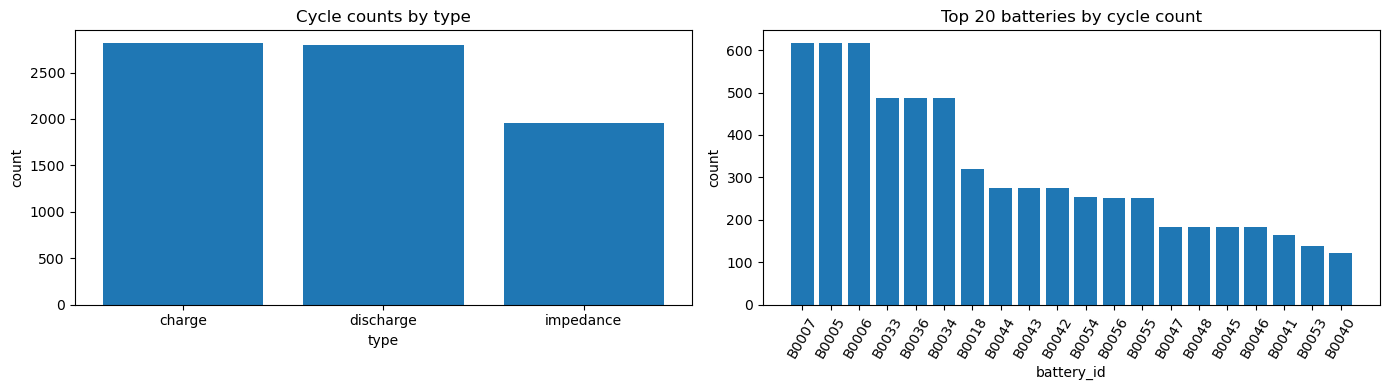

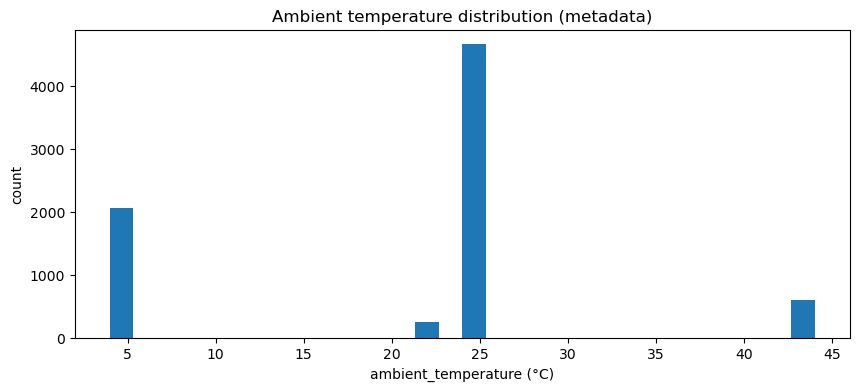

Discharge rows: 2794
Capacity missing (discharge): 25
Capacity == 0 (discharge): 19


,battery_id,test_id,Capacity
count,2794,2794.000000,2769.000000
unique,34,NaN,NaN
top,B0033,NaN,NaN
freq,197,NaN,NaN
mean,NaN,162.996063,1.326543
std,NaN,143.385837,0.472517
min,NaN,0.000000,0.000000
25%,NaN,52.000000,1.150286
50%,NaN,119.000000,1.428065
75%,NaN,236.000000,1.673645


,%_zero_capacity
battery_id,
B0048,4.166667
B0047,4.166667
B0046,4.166667
B0049,4.000000
B0051,4.000000
B0050,4.000000
B0045,2.777778
B0053,1.785714
B0054,0.970874


In [49]:
# Basic EDA on metadata
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

type_counts = meta["type"].value_counts(dropna=False)
axes[0].bar(type_counts.index.astype(str), type_counts.values)
axes[0].set_title("Cycle counts by type")
axes[0].set_xlabel("type")
axes[0].set_ylabel("count")

battery_counts = meta["battery_id"].value_counts().head(20)
axes[1].bar(battery_counts.index.astype(str), battery_counts.values)
axes[1].set_title("Top 20 batteries by cycle count")
axes[1].set_xlabel("battery_id")
axes[1].set_ylabel("count")
axes[1].tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

# Ambient temperature distribution
plt.figure(figsize=(10, 4))
plt.hist(meta["ambient_temperature"].dropna(), bins=30)
plt.title("Ambient temperature distribution (metadata)")
plt.xlabel("ambient_temperature (°C)")
plt.ylabel("count")
plt.show()

# Capacity sanity checks (discharge only)
dis_meta = meta.loc[meta["type"] == "discharge"].copy()
print("Discharge rows:", len(dis_meta))
print("Capacity missing (discharge):", int(dis_meta["Capacity"].isna().sum()))
print("Capacity == 0 (discharge):", int((dis_meta["Capacity"] == 0).sum()))
display(dis_meta[["battery_id", "test_id", "Capacity"]].describe(include="all"))

# Spot batteries with suspiciously many zero capacities
zero_by_batt = (dis_meta["Capacity"].fillna(np.nan) == 0).groupby(dis_meta["battery_id"]).mean().sort_values(ascending=False)
display((zero_by_batt * 100).to_frame("%_zero_capacity").head(15))

## 2) Validate per-cycle CSV schemas (charge / discharge / impedance)
Each `filename` in the metadata points to a CSV under `data/` with a schema that depends on `type`.

From NASA documentation (`Extra_infos/README_*.txt`):
- **charge** fields: `Voltage_measured`, `Current_measured`, `Temperature_measured`, `Current_charge`, `Voltage_charge`, `Time`
- **discharge** fields: `Voltage_measured`, `Current_measured`, `Temperature_measured`, `Current_load`, `Voltage_load`, `Time`
- **impedance** fields: `Sense_current`, `Battery_current`, `Current_ratio`, `Battery_impedance`, `Rectified_Impedance`

We will verify these columns exist and do basic sanity checks (non-empty, numeric/coercible, monotonic time for charge/discharge).

In [50]:
EXPECTED_DATA_COLS = {
    "charge": [
        "Voltage_measured",
        "Current_measured",
        "Temperature_measured",
        "Current_charge",
        "Voltage_charge",
        "Time",
    ],
    "discharge": [
        "Voltage_measured",
        "Current_measured",
        "Temperature_measured",
        "Current_load",
        "Voltage_load",
        "Time",
    ],
    "impedance": [
        "Sense_current",
        "Battery_current",
        "Current_ratio",
        "Battery_impedance",
        "Rectified_Impedance",
    ],
}

def read_csv_head_columns(path: Path) -> list[str]:
    # Read only the header line (fast)
    try:
        df0 = pd.read_csv(path, nrows=0)
        return list(df0.columns)
    except Exception as e:
        return [f"<READ_ERROR: {e}>" ]

def pick_files_to_check(meta: pd.DataFrame) -> pd.DataFrame:
    """Return a subset of meta rows to check, unless RUN_FULL_SCAN=True."""
    if RUN_FULL_SCAN:
        return meta

    rows = []
    for t, g in meta.groupby("type", dropna=False):
        if t not in EXPECTED_DATA_COLS:
            continue
        sample_n = min(SAMPLE_N_PER_TYPE, len(g))
        rows.append(g.sample(sample_n, random_state=RANDOM_SEED))
    if not rows:
        return meta.sample(min(len(meta), 10), random_state=RANDOM_SEED)
    return pd.concat(rows, ignore_index=True)

meta_check = pick_files_to_check(meta)
print("Files to schema-check:", len(meta_check), "(full scan)" if RUN_FULL_SCAN else "(sample)")

# Schema check
schema_rows = []
for _, row in meta_check.iterrows():
    path = Path(row["file_path"])
    cols = read_csv_head_columns(path)
    schema_rows.append({
        "battery_id": row["battery_id"],
        "type": row["type"],
        "test_id": row["test_id"],
        "filename": row["filename"],
        "n_cols": len(cols),
        "columns": tuple(cols),
    })
schema_df = pd.DataFrame(schema_rows)

display(schema_df.head(10))

# Summarize unique schemas per type
for t in sorted(schema_df["type"].unique()):
    unique_schemas = schema_df.loc[schema_df["type"] == t, "columns"].value_counts()
    print(f"\nType={t} unique schemas: {len(unique_schemas)}")
    display(unique_schemas.head(10))

# Column completeness vs expectation
problems = []
for _, r in schema_df.iterrows():
    expected = set(EXPECTED_DATA_COLS.get(r["type"], []))
    got = set(r["columns"])
    miss = sorted(expected - got)
    extra = sorted(got - expected)
    if miss or extra:
        problems.append({
            "battery_id": r["battery_id"],
            "type": r["type"],
            "test_id": r["test_id"],
            "filename": r["filename"],
            "missing": miss,
            "extra": extra,
        })

problems_df = pd.DataFrame(problems)
print("\nSchema mismatches found:", len(problems_df))
if len(problems_df):
    display(problems_df.head(20))

Files to schema-check: 7565 (full scan)


,battery_id,type,test_id,filename,n_cols,columns
0,B0047,discharge,0,00001.csv,6,"(Voltage_measured, Current_measured, Temperatu..."
1,B0047,impedance,1,00002.csv,5,"(Sense_current, Battery_current, Current_ratio..."
2,B0047,charge,2,00003.csv,6,"(Voltage_measured, Current_measured, Temperatu..."
3,B0047,impedance,3,00004.csv,5,"(Sense_current, Battery_current, Current_ratio..."
4,B0047,discharge,4,00005.csv,6,"(Voltage_measured, Current_measured, Temperatu..."
5,B0047,charge,5,00006.csv,6,"(Voltage_measured, Current_measured, Temperatu..."
6,B0047,discharge,6,00007.csv,6,"(Voltage_measured, Current_measured, Temperatu..."
7,B0047,charge,7,00008.csv,6,"(Voltage_measured, Current_measured, Temperatu..."
8,B0047,discharge,8,00009.csv,6,"(Voltage_measured, Current_measured, Temperatu..."
9,B0047,charge,9,00010.csv,6,"(Voltage_measured, Current_measured, Temperatu..."



Type=charge unique schemas: 1


columns
(Voltage_measured, Current_measured, Temperature_measured, Current_charge, Voltage_charge, Time)    2815
Name: count, dtype: int64


Type=discharge unique schemas: 1


columns
(Voltage_measured, Current_measured, Temperature_measured, Current_load, Voltage_load, Time)    2794
Name: count, dtype: int64


Type=impedance unique schemas: 1


columns
(Sense_current, Battery_current, Current_ratio, Battery_impedance, Rectified_Impedance)    1956
Name: count, dtype: int64


Schema mismatches found: 0


In [51]:
def parse_complex_series(s: pd.Series) -> pd.Series:
    """Parse strings like '(928.3-48.4j)' to Python complex numbers."""
    if s.dtype != object:
        return s
    cleaned = (
        s.astype(str)
         .str.strip()
         .str.replace("(", "", regex=False)
         .str.replace(")", "", regex=False)
         .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )
    def _to_complex(x: str):
        try:
            return complex(x)
        except Exception:
            return np.nan
    return cleaned.map(_to_complex)

def load_cycle_file(row: pd.Series, nrows: int | None = None) -> pd.DataFrame:
    """Load a single cycle file with light parsing."""
    path = Path(row["file_path"])
    df = pd.read_csv(path, nrows=nrows)
    df.columns = [c.strip() for c in df.columns]

    if row["type"] in ("charge", "discharge"):
        # Coerce numeric columns
        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    elif row["type"] == "impedance":
        # Parse complex-valued columns
        for c in df.columns:
            df[c] = parse_complex_series(df[c])
    return df

# Quick previews (1 example per type)
examples = []
for t in ["discharge", "charge", "impedance"]:
    sub = meta.loc[meta["type"] == t]
    if len(sub) == 0:
        continue
    examples.append(sub.iloc[0])

for ex in examples:
    df_ex = load_cycle_file(ex, nrows=8)
    print("\n=== Example cycle ===")
    print({"battery_id": ex["battery_id"], "type": ex["type"], "test_id": ex["test_id"], "filename": ex["filename"]})
    display(df_ex)


=== Example cycle ===
{'battery_id': 'B0047', 'type': 'discharge', 'test_id': np.int64(0), 'filename': '00001.csv'}


,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
0,4.246711,0.000252,6.212696,0.0002,0.000,0.000
1,4.246764,-0.001411,6.234019,0.0002,4.262,9.360
2,4.039277,-0.995093,6.250255,1.0000,3.465,23.281
3,4.019506,-0.996731,6.302176,1.0000,3.451,36.406
4,4.004763,-0.992845,6.361645,1.0000,3.438,49.625
5,3.992863,-0.995957,6.399692,1.0000,3.427,62.813
6,3.982347,-0.994665,6.233613,1.0000,3.419,75.891
7,3.972458,-0.998753,5.984854,1.0000,3.400,89.031



=== Example cycle ===
{'battery_id': 'B0047', 'type': 'charge', 'test_id': np.int64(2), 'filename': '00003.csv'}


,Voltage_measured,Current_measured,Temperature_measured,Current_charge,Voltage_charge,Time
0,3.486189,0.001417,5.990142,-0.0006,0.002,0.000
1,3.746592,1.489057,5.992528,1.4995,4.618,2.594
2,3.775438,1.490426,5.991340,1.4995,4.669,8.922
3,3.794844,1.491527,6.003554,1.4995,4.694,15.234
4,3.811691,1.491425,6.026729,1.4995,4.707,21.516
5,3.826773,1.492617,6.038672,1.4995,4.719,27.797
6,3.840722,1.492487,6.048008,1.4995,4.732,34.125
7,3.854195,1.492478,6.047619,1.4995,4.745,40.438



=== Example cycle ===
{'battery_id': 'B0047', 'type': 'impedance', 'test_id': np.int64(1), 'filename': '00002.csv'}


,Sense_current,Battery_current,Current_ratio,Battery_impedance,Rectified_Impedance
0,928.347229- 48.499577j,228.786133- 70.944817j,3.761726+0.954496j,0.190217+0.079140j,0.174930-0.023316j
1,922.005981- 52.154812j,233.297836- 67.844925j,3.703836+0.853551j,0.012482+0.036650j,0.168669-0.024717j
2,920.040588- 52.199265j,236.620758- 67.221054j,3.655870+0.817985j,0.030461-0.085294j,0.161078-0.024115j
3,914.200562- 52.371727j,242.297318- 66.459366j,3.564190+0.761470j,0.142294-0.121922j,0.149244-0.023729j
4,911.278137- 45.477928j,246.623474- 65.415016j,3.497843+0.743374j,0.243882-0.080332j,0.140498-0.022852j
5,907.116943- 46.324535j,251.115936- 65.691101j,3.426141+0.711792j,0.303109-0.011000j,0.131157-0.022424j
6,899.554443- 43.060860j,259.126465- 67.000046j,3.294223+0.685581j,0.327091+0.051457j,0.123046-0.019510j
7,891.207275- 43.172672j,266.564697- 68.215668j,3.176715+0.650983j,0.330900+0.093557j,0.113448-0.017644j


## 2.1) Preprocessing charge/discharge logs (time consistency + physical sanity checks)



The per-cycle CSVs for **charge** and **discharge** are time-series logs sampled by the test stand. Before extracting features (durations, slopes, integrals, etc.), we validate and standardize the logs so downstream computations are meaningful.



### What we check and why

- **Time monotonicity**: `Time` should increase within a cycle. Non-monotonic time usually indicates logging glitches (duplicates, resets) and can break derivatives/integrals.

- **Sampling consistency**: the sampling interval $\Delta t$ is usually close to a constant within a cycle. Large spikes in $\Delta t$ indicate missing segments.

- **Value ranges** (physical sanity): voltage, current, and temperature should stay within reasonable ranges. Extreme values often point to parsing issues or corrupted rows.

- **Charge/discharge sign conventions**: some datasets log discharge current as negative; others log magnitudes. We report the median current sign to avoid incorrect integrations.



### Physical interpretation (what typical shapes mean)

- **Charge (CC–CV)**: in lithium-ion charging, a common protocol is constant-current (CC) followed by constant-voltage (CV). During CC, current is roughly constant and voltage rises; during CV, voltage stays near a limit while current tapers down as the cell approaches saturation.

- **Discharge**: under load, voltage typically drops with time and state-of-charge; an instantaneous drop at the start reflects ohmic/internal resistance and polarization. As aging increases internal resistance, the voltage drop becomes larger.

- **Temperature**: temperature often rises during high-current portions due to Joule heating ($I^2R$) and electrochemical losses; temperature dynamics can be slow compared to voltage/current.



The next cell performs these checks on a small sample of cycles and shows example plots.

In [52]:
# Preprocessing checks for charge/discharge per-cycle logs
# When RUN_FULL_SCAN=True, this cell scans *all* charge/discharge cycles.
# To keep it feasible, it reads only a minimal set of columns (Time, voltage/current/temp if present).

from time import perf_counter

def _find_time_col(cols: list[str]) -> str | None:
    if "Time" in cols:
        return "Time"
    # Fallbacks (rare)
    for c in cols:
        if c.strip().lower() == "time":
            return c
    for c in cols:
        if "time" in c.strip().lower():
            return c
    return None

def _read_cycle_minimal(row: pd.Series) -> tuple[pd.DataFrame, dict]:
    """Read minimal columns needed for time/log checks.
    Returns (df, info) where info includes missing-column diagnostics.
    """

    path = Path(row["file_path"])
    cols = list(pd.read_csv(path, nrows=0).columns)
    cols = [c.strip() for c in cols]
    tcol = _find_time_col(cols)
    want = []
    if tcol is not None:
        want.append(tcol)

    # Common signals (if present)
    for c in ["Voltage_measured", "Current_measured", "Temperature_measured"]:
        if c in cols:
            want.append(c)
    info = {
        "has_time": tcol is not None,
        "time_col": tcol,
        "missing_time": tcol is None,
        "read_cols": want,
    }

    if not want:
        return pd.DataFrame(), info

    df = pd.read_csv(path, usecols=want)
    df.columns = [c.strip() for c in df.columns]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df, info

def _summarize_time_series_cycle(row: pd.Series) -> dict:
    out: dict = {
        "battery_id": row.get("battery_id"),
        "type": row.get("type"),
        "test_id": row.get("test_id"),
        "filename": row.get("filename"),
    }

    try:
        df, info = _read_cycle_minimal(row)
    except Exception as e:
        out.update({"status": "READ_ERROR", "error": str(e)[:200]})
        return out
    out.update(info)
    out["n_rows"] = int(len(df))
    if df.empty:
        out["status"] = "EMPTY_OR_NO_COLS"
        return out

    tcol = info.get("time_col")
    if tcol is None or tcol not in df.columns:
        out["status"] = "NO_TIME_COL"
        return out

    t = df[tcol].astype(float)
    out["t_start"] = float(t.iloc[0]) if len(t) else np.nan
    out["t_end"] = float(t.iloc[-1]) if len(t) else np.nan
    out["duration"] = float(out["t_end"] - out["t_start"]) if pd.notna(out["t_end"]) and pd.notna(out["t_start"]) else np.nan
    # Time monotonicity / dt stats
    dt = t.diff()
    out["n_nonpositive_dt"] = int((dt <= 0).sum(skipna=True))
    out["t_monotonic_increasing"] = bool(out["n_nonpositive_dt"] == 0)
    out["dt_median"] = float(dt.median(skipna=True))
    out["dt_p95"] = float(dt.quantile(0.95)) if dt.notna().any() else np.nan
    out["dt_max"] = float(dt.max(skipna=True))
    out["flag_dt_spike"] = bool(pd.notna(out["dt_median"]) and out["dt_median"] > 0 and pd.notna(out["dt_max"]) and (out["dt_max"] > 10 * out["dt_median"]))

    # Core signals (if present)
    v = df.get("Voltage_measured")
    i = df.get("Current_measured")
    temp = df.get("Temperature_measured")
    if v is not None:
        out["v_min"] = float(np.nanmin(v))
        out["v_max"] = float(np.nanmax(v))
        out["flag_v_range"] = bool((out["v_min"] < 0) or (out["v_max"] > 5.0))
    else:
        out["flag_v_range"] = False
    
    if i is not None:
        out["i_median"] = float(np.nanmedian(i))
        out["i_min"] = float(np.nanmin(i))
        out["i_max"] = float(np.nanmax(i))
        out["flag_i_range"] = bool((abs(out["i_min"]) > 10.0) or (abs(out["i_max"]) > 10.0))
        out["current_sign"] = "mostly_pos" if out["i_median"] > 0.1 else ("mostly_neg" if out["i_median"] < -0.1 else "near_zero")
    else:
        out["flag_i_range"] = False
        out["current_sign"] = "missing"
    
    if temp is not None:
        out["temp_min"] = float(np.nanmin(temp))
        out["temp_max"] = float(np.nanmax(temp))
        out["flag_temp_range"] = bool((out["temp_min"] < -20) or (out["temp_max"] > 80))
    else:
        out["flag_temp_range"] = False

    # Optional cross-check: integrate current to estimate charge throughput
    # Assumption: Time is in seconds; Ah = integral(I dt) / 3600
    if (i is not None) and dt.notna().any():
        t_sec = t.to_numpy(dtype=float)
        i_a = i.to_numpy(dtype=float)
        dQ_ah = np.trapezoid(i_a, t_sec) / 3600.0
        out["integrated_current_ah_signed"] = float(dQ_ah)
        out["integrated_current_ah_abs"] = float(abs(dQ_ah))
        if row.get("type") == "discharge":
            cap = row.get("Capacity")
            out["meta_capacity_ah"] = float(cap) if pd.notna(cap) else np.nan
            if pd.notna(cap) and cap != 0:
                out["abs_int_over_meta"] = float(abs(dQ_ah) / float(cap))
    out["flag_any_issue"] = bool((not out.get("t_monotonic_increasing", True)) or out.get("flag_dt_spike", False) or out.get("flag_v_range", False) or out.get("flag_i_range", False) or out.get("flag_temp_range", False) or out.get("missing_time", False))
    out["status"] = "OK"
    return out

# Choose cycles to scan
if RUN_FULL_SCAN:
    cycles_to_scan = meta.loc[meta["type"].isin(["charge", "discharge"])].copy()
    mode = "FULL"
else:
    # Sample small set per type
    sample_n = 3
    samples = []
    for t in ["charge", "discharge"]:
        g = meta.loc[meta["type"] == t]
        if len(g) == 0:
            continue
        samples.append(g.sample(min(sample_n, len(g)), random_state=RANDOM_SEED))
    cycles_to_scan = pd.concat(samples, ignore_index=True) if samples else pd.DataFrame()
    mode = "SAMPLE"

print(f"Preprocessing scan mode: {mode} (rows={len(cycles_to_scan)})")
t0 = perf_counter()
summaries = []
for j, (_, row) in enumerate(cycles_to_scan.iterrows(), 1):
    summaries.append(_summarize_time_series_cycle(row))
    if RUN_FULL_SCAN and (j % 250 == 0):
        dt = perf_counter() - t0
        print(f"  scanned {j}/{len(cycles_to_scan)} cycles in {dt:.1f}s")

cycle_log_report = pd.DataFrame(summaries)
display(cycle_log_report.head(20))

# Save the full per-cycle report so all rows are accessible
out_path = PROJECT_ROOT / "cycle_log_preproc_report.csv"
cycle_log_report.to_csv(out_path, index=False)
print("Saved full per-cycle report to:", out_path)

# Aggregate per-battery log integrity metrics
def _frac_true(x: pd.Series) -> float:
    return float(x.fillna(False).mean()) if len(x) else np.nan

log_quality_by_batt = (
    cycle_log_report.groupby(["battery_id"], dropna=False)
    .agg(
        n_cycles=("filename", "count"),
        frac_missing_time=("missing_time", _frac_true),
        frac_nonmonotonic_time=("t_monotonic_increasing", lambda s: float((~s.fillna(True)).mean()) if len(s) else np.nan),
        frac_dt_spike=("flag_dt_spike", _frac_true),
        frac_v_out_of_range=("flag_v_range", _frac_true),
        frac_i_out_of_range=("flag_i_range", _frac_true),
        frac_temp_out_of_range=("flag_temp_range", _frac_true),
        frac_any_issue=("flag_any_issue", _frac_true),
        duration_median=("duration", "median"),
    )
    .reset_index()
)

def _log_reco(row: pd.Series) -> str:
    # Conservative rules: exclude if persistent time issues; fixable if intermittent
    if pd.isna(row.get("n_cycles")) or row.get("n_cycles", 0) == 0:
        return "UNKNOWN"
    if (row.get("frac_missing_time", 0) > 0.05) or (row.get("frac_nonmonotonic_time", 0) > 0.05):
        return "EXCLUDE (time logging issues)"
    if row.get("frac_any_issue", 0) > 0.10:
        return "FIXABLE (intermittent log issues)"
    return "OK (logs consistent)"

log_quality_by_batt["log_recommendation"] = log_quality_by_batt.apply(_log_reco, axis=1)
display(log_quality_by_batt.sort_values(["frac_any_issue", "frac_nonmonotonic_time", "frac_dt_spike"], ascending=False).head(25))
print("\nLog recommendation counts:")
display(log_quality_by_batt["log_recommendation"].value_counts(dropna=False).to_frame("count"))

# Save the per-battery log report for downstream use
batt_out_path = PROJECT_ROOT / "battery_log_quality_report.csv"
log_quality_by_batt.to_csv(batt_out_path, index=False)

print("Saved per-battery log report to:", batt_out_path)

# A compact table to use later in screening
log_quality_by_batt = log_quality_by_batt.set_index("battery_id")


Preprocessing scan mode: FULL (rows=5609)
  scanned 250/5609 cycles in 0.9s
  scanned 500/5609 cycles in 1.8s
  scanned 750/5609 cycles in 2.7s
  scanned 1000/5609 cycles in 3.8s
  scanned 1250/5609 cycles in 6.9s
  scanned 1500/5609 cycles in 11.8s
  scanned 1750/5609 cycles in 16.1s
  scanned 2000/5609 cycles in 20.2s
  scanned 2250/5609 cycles in 23.9s
  scanned 2500/5609 cycles in 27.7s
  scanned 2750/5609 cycles in 31.8s
  scanned 3000/5609 cycles in 35.5s
  scanned 3250/5609 cycles in 39.0s
  scanned 3500/5609 cycles in 44.0s
  scanned 3750/5609 cycles in 49.3s
  scanned 4000/5609 cycles in 54.1s
  scanned 4250/5609 cycles in 59.0s
  scanned 4500/5609 cycles in 63.6s
  scanned 4750/5609 cycles in 68.4s
  scanned 5000/5609 cycles in 72.5s
  scanned 5250/5609 cycles in 77.2s
  scanned 5500/5609 cycles in 81.6s


,battery_id,type,test_id,filename,has_time,time_col,missing_time,read_cols,n_rows,t_start,t_end,duration,n_nonpositive_dt,t_monotonic_increasing,dt_median,dt_p95,dt_max,flag_dt_spike,v_min,v_max,flag_v_range,i_median,i_min,i_max,flag_i_range,current_sign,temp_min,temp_max,flag_temp_range,integrated_current_ah_signed,integrated_current_ah_abs,meta_capacity_ah,abs_int_over_meta,flag_any_issue,status
0,B0047,discharge,0,00001.csv,True,Time,False,"[Time, Voltage_measured, Current_measured, Tem...",490,0.0,6436.141,6436.141,0,True,13.125,13.40600,13.921,False,2.470612,4.246764,False,-0.995207,-1.001101,2.523886e-04,False,mostly_neg,5.008084,12.376816,False,-1.705933,1.705933,1.674305,1.018891,False,OK
1,B0047,charge,2,00003.csv,True,Time,False,"[Time, Voltage_measured, Current_measured, Tem...",1621,0.0,10803.313,10803.313,0,True,6.718,6.76600,7.532,False,3.486189,4.214595,False,0.235531,0.001417,1.494314e+00,False,mostly_pos,4.358202,8.793624,False,1.541611,1.541611,NaN,NaN,False,OK
2,B0047,discharge,4,00005.csv,True,Time,False,"[Time, Voltage_measured, Current_measured, Tem...",429,0.0,5650.265,5650.265,0,True,13.187,13.37500,13.968,False,2.477662,4.186636,False,-0.995414,-0.998142,-1.535900e-03,False,mostly_neg,5.454957,11.314903,False,-1.548536,1.548536,1.524366,1.015855,False,OK
3,B0047,charge,5,00006.csv,True,Time,False,"[Time, Voltage_measured, Current_measured, Tem...",1619,0.0,10802.078,10802.078,0,True,6.703,6.79700,7.562,False,3.252719,4.214574,False,0.264200,-0.002306,1.495911e+00,False,mostly_pos,4.161258,10.145594,False,1.537849,1.537849,NaN,NaN,False,OK
4,B0047,discharge,6,00007.csv,True,Time,False,"[Time, Voltage_measured, Current_measured, Tem...",424,0.0,5590.907,5590.907,0,True,13.203,13.37500,13.985,False,2.470710,4.199923,False,-0.995584,-1.000307,-7.456987e-04,False,mostly_neg,4.922178,11.624528,False,-1.532319,1.532319,1.508076,1.016075,False,OK
5,B0047,charge,7,00008.csv,True,Time,False,"[Time, Voltage_measured, Current_measured, Tem...",1609,0.0,10807.688,10807.688,0,True,6.735,6.82800,7.609,False,3.255399,4.214573,False,0.242517,-0.002477,1.493423e+00,False,mostly_pos,3.948085,9.371286,False,1.521518,1.521518,NaN,NaN,False,OK
6,B0047,discharge,8,00009.csv,True,Time,False,"[Time, Voltage_measured, Current_measured, Tem...",419,0.0,5543.610,5543.610,0,True,13.235,13.43700,14.015,False,2.465458,4.199569,False,-0.995532,-0.998280,3.032433e-04,False,mostly_neg,4.553269,11.092924,False,-1.511621,1.511621,1.483558,1.018916,False,OK
7,B0047,charge,9,00010.csv,True,Time,False,"[Time, Voltage_measured, Current_measured, Tem...",1598,0.0,10805.687,10805.687,0,True,6.813,6.86000,7.640,False,3.302855,4.214684,False,0.246548,-0.000778,1.494114e+00,False,mostly_pos,4.021521,9.599392,False,1.503757,1.503757,NaN,NaN,False,OK
8,B0047,discharge,10,00011.csv,True,Time,False,"[Time, Voltage_measured, Current_measured, Tem...",415,0.0,5499.046,5499.046,0,True,13.250,13.44325,14.046,False,2.465765,4.199397,False,-0.995418,-0.998683,4.220116e-04,False,mostly_neg,4.826283,11.020979,False,-1.495240,1.495240,1.467139,1.019153,False,OK
9,B0047,charge,11,00012.csv,True,Time,False,"[Time, Voltage_measured, Current_measured, Tem...",1590,0.0,10804.078,10804.078,0,True,6.844,6.89100,7.640,False,3.325621,4.214637,False,0.250526,0.000757,1.495550e+00,False,mostly_pos,3.614540,9.977435,False,1.486888,1.486888,NaN,NaN,False,OK


Saved full per-cycle report to: c:\Users\Noufel\Desktop\yacine\ensia\S5\Data mining\project\cycle_log_preproc_report.csv


,battery_id,n_cycles,frac_missing_time,frac_nonmonotonic_time,frac_dt_spike,frac_v_out_of_range,frac_i_out_of_range,frac_temp_out_of_range,frac_any_issue,duration_median,log_recommendation
1,B0006,338,0.0,0.0,0.0,0.005917,0.0,0.0,0.005917,3681.2890,OK (logs consistent)
0,B0005,338,0.0,0.0,0.0,0.002959,0.0,0.0,0.002959,3681.2890,OK (logs consistent)
2,B0007,338,0.0,0.0,0.0,0.002959,0.0,0.0,0.002959,3681.2890,OK (logs consistent)
3,B0018,266,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,4008.9300,OK (logs consistent)
4,B0025,59,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,7543.4690,OK (logs consistent)
5,B0026,59,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,7543.4690,OK (logs consistent)
6,B0027,59,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,7543.4690,OK (logs consistent)
7,B0028,59,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,7543.4690,OK (logs consistent)
8,B0029,80,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,5376.1560,OK (logs consistent)
9,B0030,80,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,5376.1560,OK (logs consistent)



Log recommendation counts:


,count
log_recommendation,
OK (logs consistent),34


Saved per-battery log report to: c:\Users\Noufel\Desktop\yacine\ensia\S5\Data mining\project\battery_log_quality_report.csv


## 3) Discharge capacity → SOH (State of Health)
For battery health, **capacity fade** is the most direct indicator.

A simple and widely used SOH definition is:
$$\text{SOH}(k) = \frac{C_k}{C_{\text{init}}}$$
where $C_k$ is the discharge capacity at cycle $k$ and $C_{\text{init}}$ is the beginning-of-life capacity.

Notes for this dataset:
- Capacity is stored directly in `metadata.csv` as `Capacity` for discharge cycles.
- Some batteries (notably cold tests like B0049–B0052) can contain **zero/invalid capacities** due to experimental issues. This notebook treats `Capacity==0` as invalid for SOH/RUL labeling unless configured otherwise.

,battery_id,discharge_cycle_idx,capacity_ah,capacity_init_ah,soh
5121,B0005,1,1.856487,1.856487,1.000000
5123,B0005,2,1.846327,1.856487,0.994527
5125,B0005,3,1.835349,1.856487,0.988614
5127,B0005,4,1.835263,1.856487,0.988567
5129,B0005,5,1.834646,1.856487,0.988235
5131,B0005,6,1.835662,1.856487,0.988782
5133,B0005,7,1.835146,1.856487,0.988504
5135,B0005,8,1.825757,1.856487,0.983447
5137,B0005,9,1.824774,1.856487,0.982917
5139,B0005,10,1.824613,1.856487,0.982831


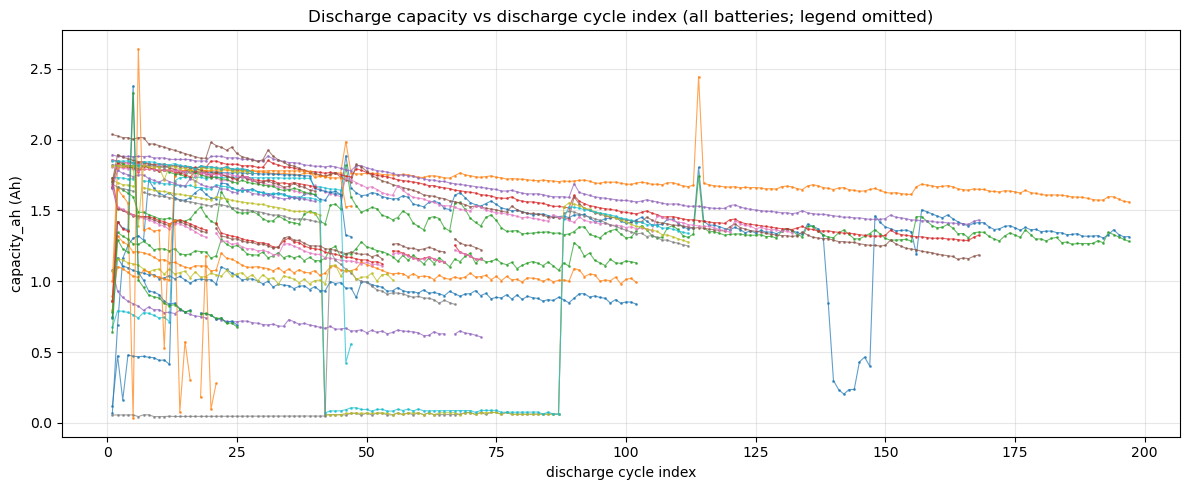

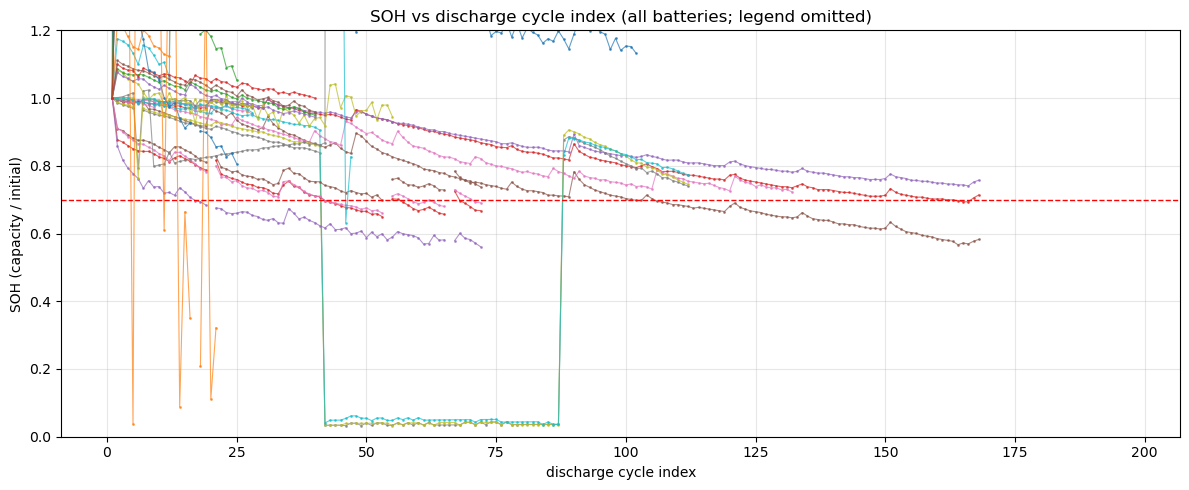

battery_id
B0050      5.0
B0045     17.0
B0042     42.0
B0043     42.0
B0044     42.0
B0046     42.0
B0047     42.0
B0040     46.0
B0048     53.0
B0006    102.0
B0005    162.0
B0007      NaN
B0018      NaN
B0025      NaN
B0026      NaN
B0027      NaN
B0028      NaN
B0029      NaN
B0030      NaN
B0031      NaN
Name: eol_cycle, dtype: float64

Batteries with no detected EOL (based on available data): 23


In [53]:
dis = meta.loc[meta["type"] == "discharge"].copy()

# Define a per-battery discharge cycle index (sorted by test_id then timestamp as tie-breaker)
dis = dis.sort_values(["battery_id", "test_id", "start_ts"])
dis["discharge_cycle_idx"] = dis.groupby("battery_id").cumcount() + 1

# Clean capacity: treat 0 as missing (common issue in some cold experiments)
dis["capacity_ah"] = dis["Capacity"].copy()
dis.loc[dis["capacity_ah"] == 0, "capacity_ah"] = np.nan

# Initial capacity per battery = first non-null capacity
init_capacity = dis.groupby("battery_id")["capacity_ah"].transform(lambda s: s.dropna().iloc[0] if s.dropna().size else np.nan)
dis["capacity_init_ah"] = init_capacity
dis["soh"] = dis["capacity_ah"] / dis["capacity_init_ah"]

# EOL threshold (default): 70% of initial capacity (30% fade)
dis["eol_threshold_ah"] = 0.7 * dis["capacity_init_ah"]
dis["is_below_eol"] = dis["capacity_ah"] <= dis["eol_threshold_ah"]

display(dis[["battery_id", "discharge_cycle_idx", "capacity_ah", "capacity_init_ah", "soh"]].head(10))

# Plot capacity trajectories for all batteries (legend omitted for readability)
all_batts = dis["battery_id"].value_counts().index.tolist()
plt.figure(figsize=(12, 5))
for bid in all_batts:
    d = dis.loc[dis["battery_id"] == bid]
    plt.plot(d["discharge_cycle_idx"], d["capacity_ah"], marker='.', linewidth=0.8, markersize=2, alpha=0.7)
plt.title("Discharge capacity vs discharge cycle index (all batteries; legend omitted)")
plt.xlabel("discharge cycle index")
plt.ylabel("capacity_ah (Ah)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot SOH trajectories for all batteries (legend omitted for readability)
plt.figure(figsize=(12, 5))
for bid in all_batts:
    d = dis.loc[dis["battery_id"] == bid]
    plt.plot(d["discharge_cycle_idx"], d["soh"], marker='.', linewidth=0.8, markersize=2, alpha=0.7)
plt.axhline(0.7, color="red", linestyle="--", linewidth=1, label="70% threshold")
plt.title("SOH vs discharge cycle index (all batteries; legend omitted)")
plt.xlabel("discharge cycle index")
plt.ylabel("SOH (capacity / initial)")
plt.ylim(0, 1.2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find EOL cycle (first time below threshold) per battery
def _first_true_index(s: pd.Series) -> float:
    idx = np.flatnonzero(s.fillna(False).to_numpy())
    if idx.size == 0:
        return np.nan
    return float(idx[0] + 1)  # discharge_cycle_idx is 1-based

eol_cycle = dis.groupby("battery_id")["is_below_eol"].apply(_first_true_index).rename("eol_cycle")
display(eol_cycle.sort_values().head(20))
print("Batteries with no detected EOL (based on available data):", int(eol_cycle.isna().sum()))

## 4) Impedance features (Re, Rct) and their relationship to degradation
Impedance measurements can provide complementary insight into internal resistance changes over aging.

In `metadata.csv`, impedance cycles include:
- `Re` (electrolyte resistance)
- `Rct` (charge transfer resistance)

We align impedance cycles to the nearest discharge cycle index for each battery and examine trends + correlation with capacity/SOH.

Aligned impedance rows: 1956


,battery_id,test_id,start_ts,Re,Rct,ambient_temperature,filename,battery_id_dis,discharge_cycle_idx,capacity_ah,soh,start_ts_dis
0,B0005,40,2008-04-18 20:55:29.859,0.044669,0.069456,24,05161.csv,B0005,20,1.847026,0.994904,2008-04-18 21:10:19.796
1,B0005,42,2008-04-18 22:39:16.312,0.046687,0.076275,24,05163.csv,B0005,20,1.847026,0.994904,2008-04-18 21:10:19.796
2,B0005,44,2008-04-19 02:14:27.015,0.044843,0.067972,24,05165.csv,B0005,21,1.847417,0.995114,2008-04-19 02:29:09.000
3,B0005,46,2008-04-19 03:57:24.187,0.046195,0.074534,24,05167.csv,B0005,21,1.847417,0.995114,2008-04-19 02:29:09.000
4,B0005,48,2008-04-19 07:32:33.656,0.045101,0.068528,24,05169.csv,B0005,22,1.836177,0.989060,2008-04-19 07:47:15.703


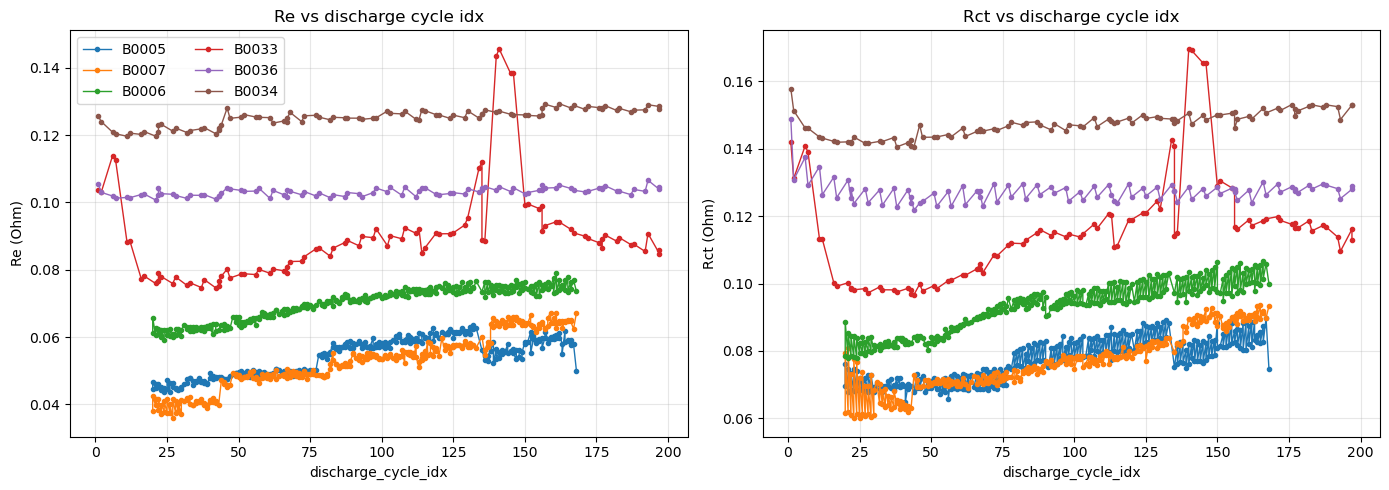

,capacity_ah,soh,Re,Rct
capacity_ah,1.000000,0.066309,0.076874,-0.076874
soh,0.066309,1.000000,0.010445,-0.010445
Re,0.076874,0.010445,1.000000,-1.000000
Rct,-0.076874,-0.010445,-1.000000,1.000000


In [54]:
imp = meta.loc[meta["type"] == "impedance"].copy()
imp = imp.sort_values(["battery_id", "test_id", "start_ts"])

# Keep relevant cols
imp = imp[["battery_id", "test_id", "start_ts", "Re", "Rct", "ambient_temperature", "filename"]].copy()

# Align impedance rows to discharge cycle index using test_id ordering (simple, consistent with preprocessing)
# If timestamps exist, alignment by time is also possible; here a robust merge_asof on test_id is used per battery.
dis_key = dis[["battery_id", "test_id", "discharge_cycle_idx", "capacity_ah", "soh", "start_ts"]].copy().sort_values(["battery_id", "test_id"])
imp_key = imp.sort_values(["battery_id", "test_id"])

# merge_asof requires sorting by merge key; do per-battery then concat
aligned = []
for bid, g in imp_key.groupby("battery_id"):
    dg = dis_key.loc[dis_key["battery_id"] == bid].sort_values("test_id")
    if dg.empty:
        continue
    ig = g.sort_values("test_id")
    m = pd.merge_asof(
        ig,
        dg,
        on="test_id",
        by=None,
        direction="nearest",
        tolerance=None,
        suffixes=("", "_dis"),
    )
    aligned.append(m)

imp_aligned = pd.concat(aligned, ignore_index=True) if aligned else pd.DataFrame()
print("Aligned impedance rows:", len(imp_aligned))
display(imp_aligned.head())

# Basic EDA plots: Re/Rct vs discharge cycle idx
if len(imp_aligned):
    top_imp_batts = imp_aligned["battery_id"].value_counts().head(6).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    for bid in top_imp_batts:
        d = imp_aligned.loc[imp_aligned["battery_id"] == bid]
        axes[0].plot(d["discharge_cycle_idx"], d["Re"], marker='.', linewidth=1, label=bid)
        axes[1].plot(d["discharge_cycle_idx"], d["Rct"], marker='.', linewidth=1, label=bid)
    axes[0].set_title("Re vs discharge cycle idx")
    axes[1].set_title("Rct vs discharge cycle idx")
    for ax in axes:
        ax.set_xlabel("discharge_cycle_idx")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel("Re (Ohm)")
    axes[1].set_ylabel("Rct (Ohm)")
    axes[0].legend(ncol=2)
    plt.tight_layout()
    plt.show()

    # Correlation (numerical)
    corr_cols = ["capacity_ah", "soh", "Re", "Rct"]
    corr = imp_aligned[corr_cols].corr(numeric_only=True)
    display(corr)
else:
    print("No impedance rows aligned (check metadata types or availability).")

## 5) Create an initial RUL target (label engineering)
A practical RUL definition for supervised learning is:
$$\text{RUL}(k) = k_{\text{EOL}} - k$$
where $k$ is the discharge cycle index and $k_{\text{EOL}}$ is the first cycle at/under an EOL threshold (here: 70% of initial capacity).

**EOL (End Of Life)**
- EOL is the point where the battery is considered no longer suitable for service under a chosen criterion.
- In this notebook, EOL is defined using **capacity fade**:
  $$C_{\text{EOL}} = 0.7 \times C_{\text{init}}$$
  and $k_{\text{EOL}}$ is the **first** discharge cycle where $C_k \le C_{\text{EOL}}$.
- EOL is application-dependent; 70% is a common convention for Li-ion aging studies and provides a clear, reproducible label.

,battery_id,discharge_cycle_idx,capacity_ah,soh,eol_cycle,rul_raw,rul,is_pre_eol
0,B0005,1,1.856487,1.000000,162.0,161.0,161.0,True
1,B0005,2,1.846327,0.994527,162.0,160.0,160.0,True
2,B0005,3,1.835349,0.988614,162.0,159.0,159.0,True
3,B0005,4,1.835263,0.988567,162.0,158.0,158.0,True
4,B0005,5,1.834646,0.988235,162.0,157.0,157.0,True
5,B0005,6,1.835662,0.988782,162.0,156.0,156.0,True
6,B0005,7,1.835146,0.988504,162.0,155.0,155.0,True
7,B0005,8,1.825757,0.983447,162.0,154.0,154.0,True
8,B0005,9,1.824774,0.982917,162.0,153.0,153.0,True
9,B0005,10,1.824613,0.982831,162.0,152.0,152.0,True


number of batteries visualized:  10


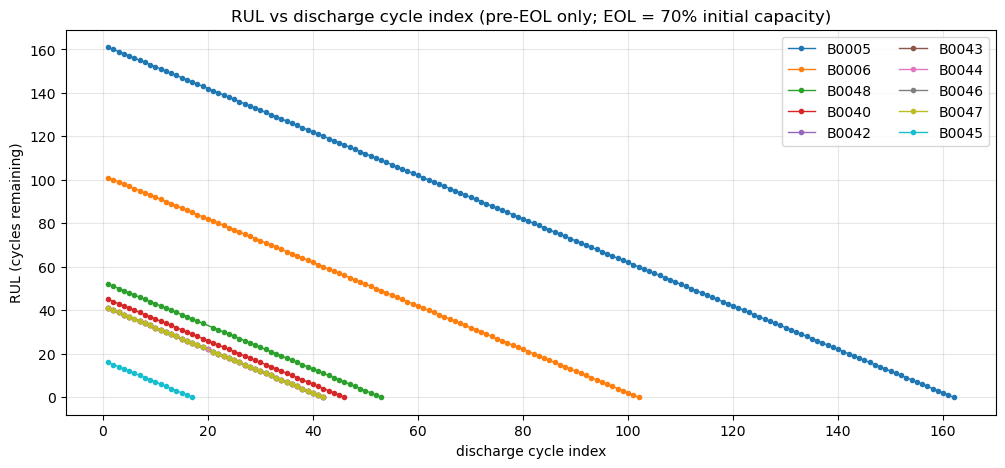

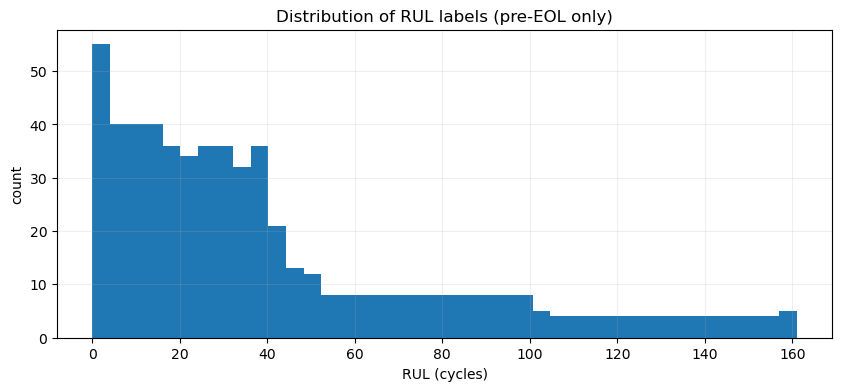

Rows with valid (capacity, SOH, RUL pre-EOL): 589


In [55]:
dis_labels = dis.copy()
dis_labels = dis_labels.merge(eol_cycle, on="battery_id", how="left")

# Raw RUL definition (can be negative after passing EOL)
dis_labels["rul_raw"] = dis_labels["eol_cycle"] - dis_labels["discharge_cycle_idx"]

# For supervised learning, it's standard to only use cycles up to EOL (RUL >= 0)
# and define RUL(EOL) = 0 (never negative).
dis_labels["rul"] = dis_labels["rul_raw"].clip(lower=0)

# RUL is only meaningful when we have an EOL cycle; also ignore rows where capacity is missing
dis_labels.loc[dis_labels["eol_cycle"].isna(), ["rul_raw", "rul"]] = np.nan
dis_labels.loc[dis_labels["capacity_ah"].isna(), ["rul_raw", "rul"]] = np.nan

# Keep a clean modeling subset (pre-EOL only)
dis_labels["is_pre_eol"] = dis_labels["rul_raw"].ge(0)
model_rul = dis_labels.loc[dis_labels["is_pre_eol"]].copy()

display(dis_labels[["battery_id", "discharge_cycle_idx", "capacity_ah", "soh", "eol_cycle", "rul_raw", "rul", "is_pre_eol"]].head(15))

# Visualize RUL trajectories for a few batteries (pre-EOL only)
BATTERIES_TO_VISUALIZE = 10
top_batts = model_rul["battery_id"].value_counts().head(BATTERIES_TO_VISUALIZE).index.tolist()
print("number of batteries visualized: " ,BATTERIES_TO_VISUALIZE)
plt.figure(figsize=(12, 5))
for bid in top_batts:
    d = model_rul.loc[model_rul["battery_id"] == bid].dropna(subset=["rul"])
    if d.empty:
        continue
    plt.plot(d["discharge_cycle_idx"], d["rul"], marker='.', linewidth=1, label=bid)
plt.title("RUL vs discharge cycle index (pre-EOL only; EOL = 70% initial capacity)")
plt.xlabel("discharge cycle index")
plt.ylabel("RUL (cycles remaining)")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.show()

# Distribution of RUL labels (pre-EOL only)
plt.figure(figsize=(10, 4))
plt.hist(model_rul["rul"].dropna(), bins=40)
plt.title("Distribution of RUL labels (pre-EOL only)")
plt.xlabel("RUL (cycles)")
plt.ylabel("count")
plt.grid(True, alpha=0.2)
plt.show()

print("Rows with valid (capacity, SOH, RUL pre-EOL):", int(model_rul.dropna(subset=["capacity_ah", "soh", "rul"]).shape[0]))

## 6) Key data-quality checks and issues to watch

Before modeling, it’s important to document and quantify data issues. Common issues in this dataset family:

- `Capacity == 0` or extremely low capacities (experiment/control software problems; documented for some batteries like B0049–B0052).

- Missing impedance parameters (`Re`, `Rct`) outside impedance cycles.

- Timestamp parsing issues (MATLAB date-vector stored as text).



The next cell collects a compact report that can be referenced in the final write-up.

## 6.1) Battery screening: which batteries to use, exclude, or “fix”
The results above show clear quality differences across batteries:
- Some batteries have **implausibly low initial capacities** (e.g., `B0041`, `B0033`, `B0039`). This can be a true battery issue, but in this dataset it is often caused by **early-cycle logging/experiment artifacts** (e.g., a “discharge” file that is mostly rest with a short current pulse). In those cases, the battery can sometimes be **salvaged by dropping the initial invalid streak** and starting from the first clearly valid charge–discharge cycle.
- Some batteries contain **many invalid capacity readings** (e.g., `B0052` shows a very high invalid fraction). These are typically not salvageable for RUL and should be excluded or treated as a special-case experiment.
- Some batteries show **intermittent glitches** (sudden drops/spikes for a short span, then returning to a reasonable trend). These can often be handled by marking those points as missing and not using them for training (or optionally interpolating small gaps).

Below, a per-battery report is built and a recommendation is assigned:
- **OK → use for RUL** (has a detected EOL + enough clean discharge cycles)
- **OK → use for SOH-only** (no detected EOL but clean enough for SOH prediction)
- **FIXABLE** (mostly OK but contains short glitch segments/outliers)
- **EXCLUDE** (too many invalid values or implausible capacities)


In [56]:
def _robust_init_capacity(cap: pd.Series, first_n_valid: int = 5) -> float:
    """Robust initial capacity estimate per battery.

    Why: the very first valid capacity can be an outlier (warm-up / logging artifact).
    We use the median of the first N valid discharge capacities when available.
    """
    v = cap.dropna().to_numpy()
    if v.size == 0:
        return np.nan
    v = v[: min(first_n_valid, v.size)]
    return float(np.median(v))


def _count_outliers_by_rolling_median(cap: pd.Series, window: int = 7, z: float = 6.0) -> int:
    """Count outliers relative to a rolling median using MAD scale (robust).
    This flags short spikes/drops that often indicate corrupted measurements.
    """
    x = cap.copy()
    if x.dropna().size < max(window, 10):
        return 0
    med = x.rolling(window=window, center=True, min_periods=max(3, window // 2)).median()
    resid = (x - med).abs()
    mad = resid.median(skipna=True)
    if not np.isfinite(mad) or mad == 0:
        return 0

    # robust z-score approximation
    robust_z = resid / (1.4826 * mad)
    return int((robust_z > z).sum(skipna=True))


def _apply_warmup_capacity_mask(
    g: pd.DataFrame,
    cap_col: str = "capacity_ah",
    frac_threshold: float = 0.60,
    prefix_low_frac: float = 0.30,
    min_prefix_len: int = 3,
) -> pd.DataFrame:
    """Mask an initial low-capacity prefix that looks like logging/experiment artifacts.

    Motivation: batteries like B0041 can show a long initial prefix of tiny capacities
    (~0.05 Ah) and later jump to a realistic regime (~1.2 Ah). For screening, we want
    the "initial capacity" to refer to the first *valid* regime, not the artifact.

    This does NOT change the raw capacity series; it creates `capacity_ah_post_warmup`
    used only for initial-capacity estimation.
    """
    g = g.sort_values("discharge_cycle_idx").copy()

    cap = pd.to_numeric(g[cap_col], errors="coerce").to_numpy(dtype=float)
    n_finite = int(np.isfinite(cap).sum())

    g["capacity_ah_post_warmup"] = g[cap_col]
    g["warmup_dropped_n"] = 0
    g["warmup_first_valid_test_id"] = np.nan

    if n_finite < 10:
        return g

    # Reference from the high end (robust to early corrupted small values)
    cap_ref = float(np.nanquantile(cap, 0.90))
    if not np.isfinite(cap_ref) or cap_ref <= 0:
        return g

    thr = frac_threshold * cap_ref
    idx_candidates = np.where(np.isfinite(cap) & (cap >= thr))[0]
    if idx_candidates.size == 0:
        return g

    first_valid_idx = int(idx_candidates[0])
    if first_valid_idx < min_prefix_len:
        return g

    prefix = cap[:first_valid_idx]
    prefix_med = float(np.nanmedian(prefix)) if np.isfinite(prefix).any() else np.nan
    if not np.isfinite(prefix_med):
        return g

    # Only drop prefix if it is clearly "too small" relative to the later regime
    if prefix_med < (prefix_low_frac * cap_ref):
        g.loc[g.index[:first_valid_idx], "capacity_ah_post_warmup"] = np.nan
        g["warmup_dropped_n"] = first_valid_idx
        g["warmup_first_valid_test_id"] = float(g.iloc[first_valid_idx].get("test_id", np.nan))

    return g


def build_battery_quality_table(dis_df: pd.DataFrame, meta_df: pd.DataFrame, eol: pd.Series) -> pd.DataFrame:
    """Aggregate discharge-level and metadata-level info into one per-battery table."""
    d = dis_df.copy()
    m = meta_df.copy()

    # Add a "post warm-up" capacity series for initial capacity estimation
    d = d.sort_values(["battery_id", "discharge_cycle_idx"])
    d = d.groupby("battery_id", group_keys=False).apply(_apply_warmup_capacity_mask)

    # Temperature summary (use discharge rows if present; fallback to all rows)
    temp_by_batt = (
        m.loc[m["type"].isin(["discharge"]), ["battery_id", "ambient_temperature"]]
        .groupby("battery_id")["ambient_temperature"]
        .agg(["median", "min", "max"])
        .rename(columns={"median": "temp_median_c", "min": "temp_min_c", "max": "temp_max_c"})
    )

    if temp_by_batt.empty:
        temp_by_batt = (
            m.groupby("battery_id")["ambient_temperature"]
            .agg(["median", "min", "max"])
            .rename(columns={"median": "temp_median_c", "min": "temp_min_c", "max": "temp_max_c"})
        )

    # Per-battery discharge stats
    grp = d.groupby("battery_id", dropna=False)
    out = (
        pd.DataFrame(
            {
                "n_discharge": grp.size(),
                "n_valid_capacity": grp["capacity_ah"].apply(lambda s: int(s.notna().sum())),
                "frac_invalid_capacity": grp["capacity_ah"].apply(lambda s: float(s.isna().mean())),
                "warmup_dropped_n": grp["warmup_dropped_n"].max(),
                "warmup_first_valid_test_id": grp["warmup_first_valid_test_id"].max(),
                "init_capacity_first_valid": grp["capacity_ah_post_warmup"].apply(
                    lambda s: float(s.dropna().iloc[0]) if s.dropna().size else np.nan
                ),
                "init_capacity_robust": grp["capacity_ah_post_warmup"].apply(_robust_init_capacity),
                "capacity_median": grp["capacity_ah"].median(),
                "capacity_min": grp["capacity_ah"].min(),
                "capacity_max": grp["capacity_ah"].max(),
                "n_outlier_points": grp["capacity_ah"].apply(_count_outliers_by_rolling_median),
                "max_discharge_cycle_idx": grp["discharge_cycle_idx"].max(),
            }
        )
        .reset_index()
    )

    out = out.merge(temp_by_batt.reset_index(), on="battery_id", how="left")
    out = out.merge(eol.rename("eol_cycle").reset_index(), on="battery_id", how="left")
    out["has_eol"] = out["eol_cycle"].notna()

    # Simple heuristics for recommendations
    # (These are transparent rules to guide decisions; adjust thresholds if domain constraints exist.)
    out["flag_very_low_init"] = out["init_capacity_robust"] < 0.5
    out["flag_low_init"] = (out["init_capacity_robust"] >= 0.5) & (out["init_capacity_robust"] < 0.8)
    out["flag_high_invalid"] = out["frac_invalid_capacity"] > 0.2
    out["flag_some_invalid"] = (out["frac_invalid_capacity"] > 0.02) & (out["frac_invalid_capacity"] <= 0.2)
    out["flag_outliers"] = out["n_outlier_points"] > 0

    # Recommended use categories
    def _recommend(row: pd.Series) -> str:
        if row["n_valid_capacity"] < 30:
            return "EXCLUDE (too few valid discharge capacities)"
        if row["flag_very_low_init"]:
            return "EXCLUDE (implausibly low initial capacity)"
        if row["flag_high_invalid"]:
            return "EXCLUDE (too many invalid capacities)"
        if row["flag_outliers"] or row["flag_some_invalid"]:

            # Fixable if the issue is intermittent and not overwhelming
            if row["has_eol"]:
                return "FIXABLE → use for RUL after cleaning"
            return "FIXABLE → use for SOH after cleaning"

        if row["has_eol"]:
            return "OK → use for RUL"
        return "OK → use for SOH-only (no EOL detected)"

    out["recommendation"] = out.apply(_recommend, axis=1)

    # Sort to show most problematic first (then by invalid fraction)
    out = out.sort_values(
        ["flag_high_invalid", "flag_very_low_init", "frac_invalid_capacity", "n_outlier_points"],
        ascending=[False, False, False, False],
    )
    return out


battery_quality = build_battery_quality_table(dis, meta, eol_cycle)

# Merge per-battery log integrity (if available from preprocessing scan)
if "log_quality_by_batt" in globals():
    battery_quality = battery_quality.merge(
        log_quality_by_batt.reset_index(),
        on="battery_id",
        how="left",
    )

    battery_quality["recommendation_capacity"] = battery_quality["recommendation"]

    def _combine_recommendation(row: pd.Series) -> str:
        cap_rec = row.get("recommendation_capacity")
        log_rec = row.get("log_recommendation")
        if isinstance(log_rec, str) and log_rec.startswith("EXCLUDE"):
            return "EXCLUDE (time/log issues)"
        if isinstance(log_rec, str) and log_rec.startswith("FIXABLE"):
            if isinstance(cap_rec, str) and cap_rec.startswith("OK"):
                return "FIXABLE → use after cleaning (time/log issues)"
            if isinstance(cap_rec, str) and cap_rec.startswith("EXCLUDE"):
                return cap_rec
            return cap_rec if isinstance(cap_rec, str) else "FIXABLE (time/log issues)"
        return cap_rec

    battery_quality["recommendation"] = battery_quality.apply(_combine_recommendation, axis=1)

else:
    battery_quality["recommendation_capacity"] = battery_quality["recommendation"]

display(battery_quality.head(25))
print("\n--- Suggested battery groups (capacity + log integrity) ---")

exclude_batts = battery_quality.loc[
    battery_quality["recommendation"].str.startswith("EXCLUDE"), "battery_id"
].tolist()

fixable_batts = battery_quality.loc[
    battery_quality["recommendation"].str.startswith("FIXABLE"), "battery_id"
].tolist()

ok_rul_batts = battery_quality.loc[
    battery_quality["recommendation"].eq("OK → use for RUL"), "battery_id"
].tolist()

ok_soh_only_batts = battery_quality.loc[
    battery_quality["recommendation"].str.startswith("OK → use for SOH-only"), "battery_id"
].tolist()

print("EXCLUDE:", exclude_batts)
print("FIXABLE:", fixable_batts)
print("OK for RUL:", ok_rul_batts)
print("OK for SOH-only:", ok_soh_only_batts)


C:\Users\Noufel\AppData\Local\Temp\ipykernel_15788\2994325428.py:95: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  d = d.groupby("battery_id", group_keys=False).apply(_apply_warmup_capacity_mask)


,battery_id,n_discharge,n_valid_capacity,frac_invalid_capacity,warmup_dropped_n,warmup_first_valid_test_id,init_capacity_first_valid,init_capacity_robust,capacity_median,capacity_min,capacity_max,n_outlier_points,max_discharge_cycle_idx,temp_median_c,temp_min_c,temp_max_c,eol_cycle,has_eol,flag_very_low_init,flag_low_init,flag_high_invalid,flag_some_invalid,flag_outliers,recommendation,n_cycles,frac_missing_time,frac_nonmonotonic_time,frac_dt_spike,frac_v_out_of_range,frac_i_out_of_range,frac_temp_out_of_range,frac_any_issue,duration_median,log_recommendation,recommendation_capacity
0,B0052,25,4,0.840000,0,NaN,0.860659,1.361139,1.361139,0.860659,1.418310,0,25,4.0,4,4,NaN,False,False,False,True,False,False,EXCLUDE (too few valid discharge capacities),50,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,4997.2265,OK (logs consistent),EXCLUDE (too few valid discharge capacities)
1,B0050,25,20,0.200000,0,NaN,0.863145,1.551756,1.265986,0.032558,2.640149,2,25,4.0,4,4,5.0,True,False,False,False,True,True,EXCLUDE (too few valid discharge capacities),50,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,4997.2265,OK (logs consistent),EXCLUDE (too few valid discharge capacities)
2,B0046,72,69,0.041667,0,NaN,1.728239,1.503121,1.253085,1.123711,1.728239,3,72,4.0,4,4,42.0,True,False,False,False,True,True,FIXABLE → use for RUL after cleaning,144,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,8619.0780,OK (logs consistent),FIXABLE → use for RUL after cleaning
3,B0048,72,69,0.041667,0,NaN,1.657996,1.498922,1.265883,1.157683,1.657996,3,72,4.0,4,4,53.0,True,False,False,False,True,True,FIXABLE → use for RUL after cleaning,144,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,8619.0780,OK (logs consistent),FIXABLE → use for RUL after cleaning
4,B0047,72,69,0.041667,0,NaN,1.674305,1.508076,1.212925,1.105977,1.674305,1,72,4.0,4,4,42.0,True,False,False,False,True,True,FIXABLE → use for RUL after cleaning,144,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,8619.0780,OK (logs consistent),FIXABLE → use for RUL after cleaning
5,B0049,25,24,0.040000,0,NaN,0.858373,1.372852,0.841322,0.691389,2.378644,3,25,4.0,4,4,NaN,False,False,False,False,True,True,EXCLUDE (too few valid discharge capacities),50,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,4997.2265,OK (logs consistent),EXCLUDE (too few valid discharge capacities)
6,B0051,25,24,0.040000,0,NaN,0.643474,1.228894,0.814566,0.643474,2.330873,3,25,4.0,4,4,NaN,False,False,False,False,True,True,EXCLUDE (too few valid discharge capacities),50,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,4997.2265,OK (logs consistent),EXCLUDE (too few valid discharge capacities)
7,B0045,72,70,0.027778,0,NaN,1.081979,0.885194,0.691296,0.606948,1.081979,1,72,4.0,4,4,17.0,True,False,False,False,True,True,FIXABLE → use for RUL after cleaning,144,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,8619.0780,OK (logs consistent),FIXABLE → use for RUL after cleaning
8,B0053,56,55,0.017857,0,NaN,1.069142,1.130586,1.046588,0.980133,1.154073,0,56,4.0,4,4,NaN,False,False,False,False,False,False,OK → use for SOH-only (no EOL detected),111,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,2560.6880,OK (logs consistent),OK → use for SOH-only (no EOL detected)
9,B0054,103,102,0.009709,0,NaN,0.739935,1.096030,0.936209,0.739935,1.166544,2,103,4.0,4,4,NaN,False,False,False,False,False,True,FIXABLE → use for SOH after cleaning,205,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,2826.0000,OK (logs consistent),FIXABLE → use for SOH after cleaning



--- Suggested battery groups (capacity + log integrity) ---
EXCLUDE: ['B0052', 'B0050', 'B0049', 'B0051', 'B0026', 'B0028', 'B0025', 'B0027']
FIXABLE: ['B0046', 'B0048', 'B0047', 'B0045', 'B0054', 'B0043', 'B0044', 'B0042', 'B0005', 'B0007', 'B0041', 'B0040', 'B0038', 'B0018', 'B0039', 'B0033', 'B0034', 'B0036', 'B0029', 'B0030', 'B0031', 'B0032', 'B0055', 'B0056']
OK for RUL: ['B0006']
OK for SOH-only: ['B0053']


In [57]:
# Sanity-check example: some "very low initial capacity" batteries are salvageable
# if the *early* discharge files are not true discharge cycles.

from pathlib import Path


def _discharge_signature_from_file(csv_path: Path) -> dict:
    df = pd.read_csv(csv_path)
    t = pd.to_numeric(df.get("Time"), errors="coerce").to_numpy(dtype=float)
    i = pd.to_numeric(df.get("Current_measured"), errors="coerce").to_numpy(dtype=float)
    v = pd.to_numeric(df.get("Voltage_measured"), errors="coerce").to_numpy(dtype=float)

    m = np.isfinite(t) & np.isfinite(i)
    t, i = t[m], i[m]
    if t.size < 3:
        return {"n": int(t.size), "duration_s": np.nan, "frac_i_lt_-0.5": np.nan, "ah_est": np.nan}

    order = np.argsort(t)
    t, i = t[order], i[order]
    i_dis = np.minimum(i, 0.0)
    ah = -np.trapezoid(i_dis, t) / 3600.0

    return {
        "n": int(t.size),
        "duration_s": float(t.max() - t.min()),
        "frac_i_lt_-0.5": float((i < -0.5).mean()),
        "i_median": float(np.median(i)),
        "i_min": float(np.min(i)),
        "v_min": float(np.nanmin(v)) if np.isfinite(v).any() else np.nan,
        "v_max": float(np.nanmax(v)) if np.isfinite(v).any() else np.nan,
        "ah_est": float(ah),
    }


batt = "B0041"
root = Path("data")

candidate = meta.loc[
    (meta["battery_id"] == batt)
    & (meta["type"] == "discharge")
    & (meta["test_id"].isin([0, 103])),
    ["battery_id", "test_id", "filename", "Capacity"],
].sort_values("test_id")

display(candidate)

if not candidate.empty:
    sig = []
    for _, r in candidate.iterrows():
        sig.append({"test_id": int(r["test_id"]), **_discharge_signature_from_file(root / r["filename"])})
    display(pd.DataFrame(sig).sort_values("test_id"))

print(
    "\nInterpretation: if `frac_i_lt_-0.5` is very small and `ah_est` is tiny, "
    "the file is not a real discharge cycle (mostly rest/pulses), and dropping the early streak is reasonable."
)


,battery_id,test_id,filename,Capacity
2995,B0041,0,02996.csv,0.055620
3098,B0041,103,03099.csv,1.215649


,test_id,n,duration_s,frac_i_lt_-0.5,i_median,i_min,v_min,v_max,ah_est
0,0,95,1063.609,0.063158,-0.002712,-4.027231,1.948762,4.187297,0.074111
1,103,457,5608.781,0.849015,-1.005925,-1.008481,1.998495,4.146040,1.330986



Interpretation: if `frac_i_lt_-0.5` is very small and `ah_est` is tiny, the file is not a real discharge cycle (mostly rest/pulses), and dropping the early streak is reasonable.


## 6.2) “Flexible” batteries: recommended fix per battery
For batteries marked **FIXABLE**, we output an actionable **fix plan** per battery:
- **Drop warm-up prefix**: remove an initial streak of unrealistically low discharge capacities (logging artifact) and start from the first valid regime.
- **Drop / mask outliers**: mark isolated spikes/drops as missing (do not train on them).
- **Interpolate short gaps** (optional): only for small missing runs if a model requires contiguous sequences (keep a mask feature).

The table below is meant to be directly reusable in the report/write-up.


In [58]:
def build_fix_plan_table(bq: pd.DataFrame) -> pd.DataFrame:
    """Build a per-battery fix plan (for FIXABLE batteries).

    Uses only columns already computed in `battery_quality`.
    """
    if bq is None or bq.empty:
        return pd.DataFrame()

    df = bq.copy()

    def _fix_actions(row: pd.Series) -> tuple[str, str]:
        actions = []
        details = []

        warmup_n = row.get("warmup_dropped_n")
        warmup_tid = row.get("warmup_first_valid_test_id")
        if pd.notna(warmup_n) and float(warmup_n) > 0:
            actions.append("drop_warmup_prefix")
            if pd.notna(warmup_tid):
                details.append(f"drop first {int(warmup_n)} discharge cycles (start at test_id≈{int(warmup_tid)})")
            else:
                details.append(f"drop first {int(warmup_n)} discharge cycles")

        # Invalid / missing capacity points
        frac_invalid = float(row.get("frac_invalid_capacity", np.nan)) if pd.notna(row.get("frac_invalid_capacity", np.nan)) else np.nan
        if np.isfinite(frac_invalid) and frac_invalid > 0:
            actions.append("mask_invalid_capacity")
            details.append(f"mask missing/zero capacity points (invalid frac≈{frac_invalid:.2%})")

            # Only suggest interpolation when invalid fraction is small-ish
            if frac_invalid <= 0.10:
                actions.append("interpolate_short_gaps_optional")
                details.append("optional: interpolate only short NaN runs; keep a mask feature")

        # Outliers
        n_out = row.get("n_outlier_points")
        if pd.notna(n_out) and int(n_out) > 0:
            actions.append("mask_outliers")
            details.append(f"mask local spikes/drops (detected outlier points≈{int(n_out)})")

        # Time/log issues (if present)
        log_rec = row.get("log_recommendation")
        if isinstance(log_rec, str) and log_rec.startswith("FIXABLE"):
            actions.append("fix_time_log")
            details.append("check timestamps/ordering; drop duplicated or inconsistent rows")

        if not actions:
            actions = ["none"]
            details = ["no cleaning needed beyond standard NaN handling"]

        return ("; ".join(actions), "; ".join(details))

    df[["fix_actions", "fix_details"]] = df.apply(lambda r: pd.Series(_fix_actions(r)), axis=1)

    # Focus on FIXABLE batteries only
    out = df.loc[df["recommendation"].astype(str).str.startswith("FIXABLE")].copy()

    cols = [
        "battery_id",
        "recommendation",
        "fix_actions",
        "fix_details",
        "warmup_dropped_n",
        "warmup_first_valid_test_id",
        "n_valid_capacity",
        "frac_invalid_capacity",
        "n_outlier_points",
        "init_capacity_robust",
    ]
    cols = [c for c in cols if c in out.columns]

    out = out[cols].sort_values(["warmup_dropped_n", "frac_invalid_capacity", "n_outlier_points"], ascending=[False, False, False])
    return out


fix_plan = build_fix_plan_table(battery_quality)
print("FIXABLE batteries:", int(fix_plan.shape[0]))
display(fix_plan)


FIXABLE batteries: 24


,battery_id,recommendation,fix_actions,fix_details,warmup_dropped_n,warmup_first_valid_test_id,n_valid_capacity,frac_invalid_capacity,n_outlier_points,init_capacity_robust
15,B0041,FIXABLE → use for SOH after cleaning,drop_warmup_prefix; mask_outliers,drop first 42 discharge cycles (start at test_...,42,103.0,67,0.000000,22,1.119457
19,B0039,FIXABLE → use for SOH after cleaning,drop_warmup_prefix; mask_outliers,drop first 12 discharge cycles (start at test_...,12,32.0,47,0.000000,8,1.770404
2,B0046,FIXABLE → use for RUL after cleaning,mask_invalid_capacity; interpolate_short_gaps_...,mask missing/zero capacity points (invalid fra...,0,NaN,69,0.041667,3,1.503121
3,B0048,FIXABLE → use for RUL after cleaning,mask_invalid_capacity; interpolate_short_gaps_...,mask missing/zero capacity points (invalid fra...,0,NaN,69,0.041667,3,1.498922
4,B0047,FIXABLE → use for RUL after cleaning,mask_invalid_capacity; interpolate_short_gaps_...,mask missing/zero capacity points (invalid fra...,0,NaN,69,0.041667,1,1.508076
7,B0045,FIXABLE → use for RUL after cleaning,mask_invalid_capacity; interpolate_short_gaps_...,mask missing/zero capacity points (invalid fra...,0,NaN,70,0.027778,1,0.885194
9,B0054,FIXABLE → use for SOH after cleaning,mask_invalid_capacity; interpolate_short_gaps_...,mask missing/zero capacity points (invalid fra...,0,NaN,102,0.009709,2,1.096030
10,B0043,FIXABLE → use for RUL after cleaning,mask_invalid_capacity; interpolate_short_gaps_...,mask missing/zero capacity points (invalid fra...,0,NaN,111,0.008929,53,1.681491
11,B0044,FIXABLE → use for RUL after cleaning,mask_invalid_capacity; interpolate_short_gaps_...,mask missing/zero capacity points (invalid fra...,0,NaN,111,0.008929,39,1.653401
12,B0042,FIXABLE → use for RUL after cleaning,mask_invalid_capacity; interpolate_short_gaps_...,mask missing/zero capacity points (invalid fra...,0,NaN,111,0.008929,30,1.728235


### 6.2.1) Examples: where to apply the fix
Below we plot a few **representative FIXABLE batteries** and highlight *where* to apply the recommended cleaning:
- **Warm-up prefix** (shaded): drop the first cycles before the battery enters the realistic capacity regime.
- **Invalid points** (black markers at 0): missing/zero capacity points that should be masked.
- **Outliers** (red markers): isolated spikes/drops that should be masked.
- **Short gaps** (orange markers): short NaN runs that can be optionally interpolated (only if needed by the model).


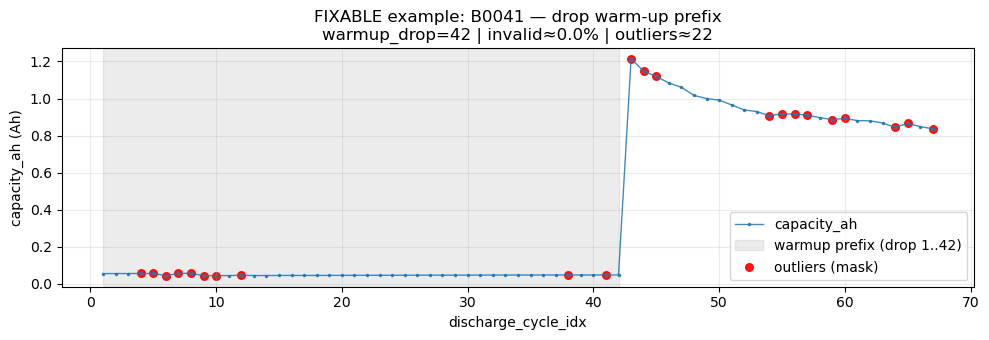

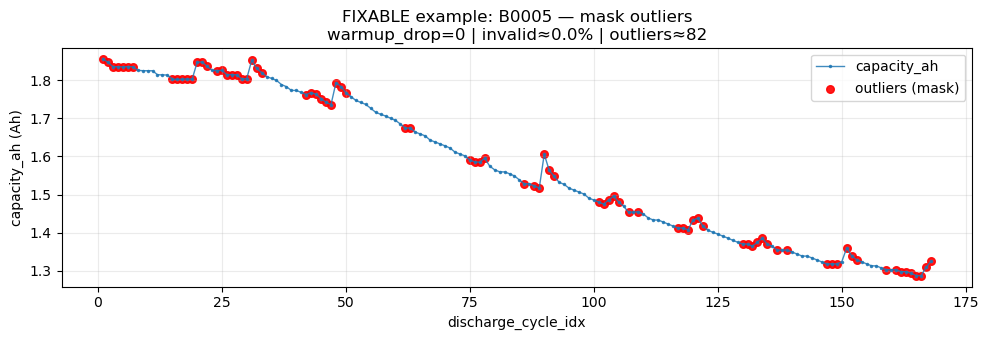

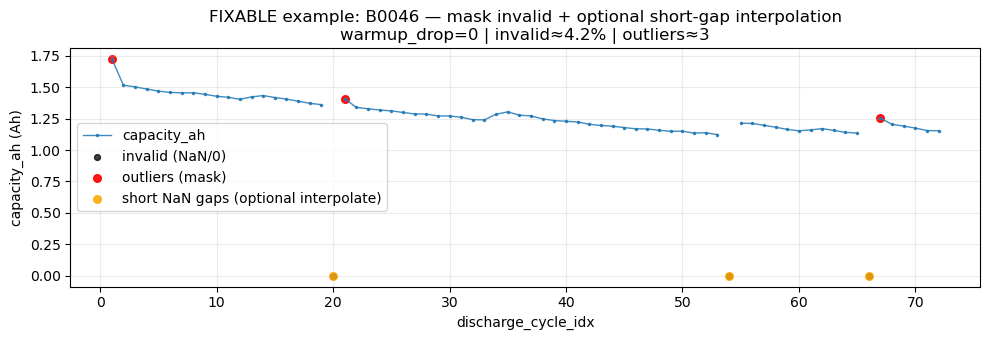

,battery_id,reason,drop_warmup_cycles,mask_outlier_cycles,mask_invalid_cycles,short_gap_cycles_optional_interp
0,B0041,drop warm-up prefix,1..42,"[4, 5, 6, 7, 8, 9, 10, 12, 38, 41, 43, 44, 45,...",[],[]
1,B0005,mask outliers,-,"[1, 2, 3, 4, 5, 6, 7, 15, 16, 17, 18, 19, 20, ...",[],[]
2,B0046,mask invalid + optional short-gap interpolation,-,"[1, 21, 67]","[20, 54, 66]","[20, 54, 66]"


In [59]:
def _outlier_mask_by_rolling_median(cap: pd.Series, window: int = 7, z: float = 6.0) -> pd.Series:
    x = pd.to_numeric(cap, errors="coerce")
    if x.dropna().size < max(window, 10):
        return pd.Series(False, index=x.index)

    med = x.rolling(window=window, center=True, min_periods=max(3, window // 2)).median()
    resid = (x - med).abs()
    mad = resid.median(skipna=True)
    if not np.isfinite(mad) or mad == 0:
        return pd.Series(False, index=x.index)

    robust_z = resid / (1.4826 * mad)
    return robust_z > z


def _short_nan_gap_mask(cap: pd.Series, max_gap_len: int = 2) -> pd.Series:
    """Mask positions that are NaN and belong to a short consecutive NaN run."""
    s = pd.to_numeric(cap, errors="coerce")
    is_nan = s.isna().to_numpy()
    mask = np.zeros_like(is_nan, dtype=bool)
    i = 0
    while i < len(is_nan):
        if not is_nan[i]:
            i += 1
            continue
        j = i
        while j < len(is_nan) and is_nan[j]:
            j += 1
        run_len = j - i
        if 1 <= run_len <= max_gap_len:
            mask[i:j] = True
        i = j
    return pd.Series(mask, index=s.index)


def plot_fixable_example(bid: str, bq_row: pd.Series, dis_df: pd.DataFrame, reason: str) -> pd.DataFrame:
    d = dis_df.loc[dis_df["battery_id"] == bid].sort_values("discharge_cycle_idx").copy()
    if d.empty:
        print(f"No discharge rows for {bid}")
        return pd.DataFrame()

    x = d["discharge_cycle_idx"].to_numpy(dtype=int)
    y = pd.to_numeric(d["capacity_ah"], errors="coerce")

    warmup_n = int(bq_row.get("warmup_dropped_n", 0) or 0)
    outlier_mask = _outlier_mask_by_rolling_median(y, window=7, z=6.0)
    invalid_mask = y.isna()
    short_gap_mask = _short_nan_gap_mask(y, max_gap_len=2)

    plt.figure(figsize=(10, 3.5))
    plt.plot(x, y, marker=".", linewidth=1, markersize=3, alpha=0.85, label="capacity_ah")

    # Warmup prefix shading
    if warmup_n > 0:
        plt.axvspan(x.min(), warmup_n, alpha=0.15, color="gray", label=f"warmup prefix (drop 1..{warmup_n})")

    # Invalid points
    if invalid_mask.any():
        plt.scatter(x[invalid_mask.to_numpy()], np.zeros(int(invalid_mask.sum())), s=18, alpha=0.75, color="black", label="invalid (NaN/0)")

    # Outliers
    if outlier_mask.any():
        plt.scatter(x[outlier_mask.to_numpy()], y[outlier_mask], s=30, alpha=0.9, color="red", label="outliers (mask)")

    # Short gaps (subset of invalid)
    if short_gap_mask.any():
        plt.scatter(x[short_gap_mask.to_numpy()], np.zeros(int(short_gap_mask.sum())), s=30, alpha=0.85, color="orange", label="short NaN gaps (optional interpolate)")

    title = (
        f"FIXABLE example: {bid} — {reason}\n"
        f"warmup_drop={warmup_n} | invalid≈{float(bq_row.get('frac_invalid_capacity',0)):.1%} | outliers≈{int(bq_row.get('n_outlier_points',0) or 0)}"
    )
    plt.title(title)
    plt.xlabel("discharge_cycle_idx")
    plt.ylabel("capacity_ah (Ah)")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

    # Return a compact "where to fix" table
    outlier_cycles = x[outlier_mask.to_numpy()].tolist()
    invalid_cycles = x[invalid_mask.to_numpy()].tolist()
    short_gap_cycles = x[short_gap_mask.to_numpy()].tolist()

    where = {
        "battery_id": bid,
        "reason": reason,
        "drop_warmup_cycles": f"1..{warmup_n}" if warmup_n > 0 else "-",
        "mask_outlier_cycles": outlier_cycles[:25],
        "mask_invalid_cycles": invalid_cycles[:25],
        "short_gap_cycles_optional_interp": short_gap_cycles[:25],
    }
    return pd.DataFrame([where])


def show_fixable_examples(bq: pd.DataFrame, dis_df: pd.DataFrame) -> pd.DataFrame:
    if bq is None or bq.empty:
        print("battery_quality is empty")
        return pd.DataFrame()

    fx = bq.loc[bq["recommendation"].astype(str).str.startswith("FIXABLE")].copy()
    if fx.empty:
        print("No FIXABLE batteries.")
        return pd.DataFrame()

    examples = []

    # 1) Warmup-prefix example
    cand = fx.loc[fx.get("warmup_dropped_n", 0).fillna(0) > 0].sort_values("warmup_dropped_n", ascending=False)
    if not cand.empty:
        r = cand.iloc[0]
        examples.append(plot_fixable_example(str(r["battery_id"]), r, dis_df, reason="drop warm-up prefix"))

    # 2) Outliers example
    cand = fx.loc[fx.get("n_outlier_points", 0).fillna(0) > 0].sort_values("n_outlier_points", ascending=False)
    if not cand.empty:
        r = cand.iloc[0]
        examples.append(plot_fixable_example(str(r["battery_id"]), r, dis_df, reason="mask outliers"))

    # 3) Small invalid fraction example (optional interpolation)
    cand = fx.loc[(fx["frac_invalid_capacity"] > 0) & (fx["frac_invalid_capacity"] <= 0.10)].sort_values("frac_invalid_capacity", ascending=False)
    if not cand.empty:
        r = cand.iloc[0]
        examples.append(plot_fixable_example(str(r["battery_id"]), r, dis_df, reason="mask invalid + optional short-gap interpolation"))

    out = pd.concat([e for e in examples if isinstance(e, pd.DataFrame) and not e.empty], ignore_index=True) if examples else pd.DataFrame()
    display(out)
    return out


fixable_examples_where_to_fix = show_fixable_examples(battery_quality, dis)


## 6.3) Excluded batteries: example plots and reasons
To make exclusions defensible in the report, we automatically select **one example battery** for each exclusion reason and plot its discharge capacity trajectory.


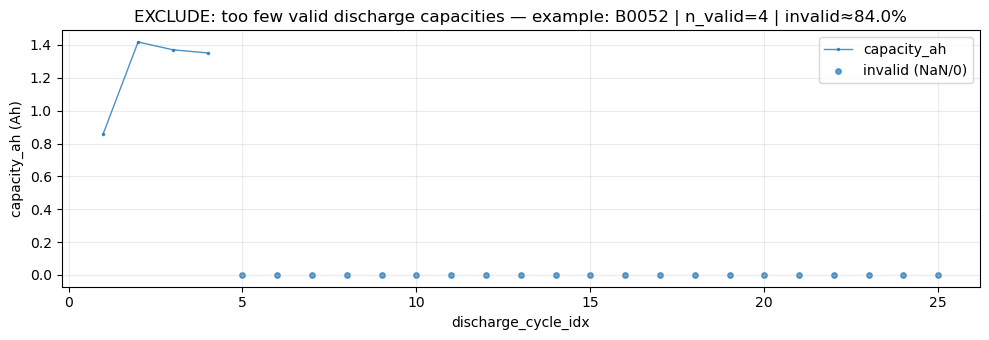

,reason,battery_id,recommendation,n_valid_capacity,frac_invalid_capacity,init_capacity_robust
0,EXCLUDE: too few valid discharge capacities,B0052,EXCLUDE (too few valid discharge capacities),4,0.84,1.361139


In [60]:
def _plot_capacity_trace_for_battery(battery_id: str, dis_df: pd.DataFrame, title: str) -> None:
    d = dis_df.loc[dis_df["battery_id"] == battery_id].sort_values("discharge_cycle_idx").copy()
    if d.empty:
        print(f"No discharge rows for {battery_id}")
        return

    x = d["discharge_cycle_idx"].to_numpy()
    y = pd.to_numeric(d["capacity_ah"], errors="coerce")

    plt.figure(figsize=(10, 3.5))
    plt.plot(x, y, marker=".", linewidth=1, markersize=3, alpha=0.8, label="capacity_ah")

    # Highlight invalid points
    invalid_mask = y.isna()
    if invalid_mask.any():
        plt.scatter(x[invalid_mask.to_numpy()], np.zeros(int(invalid_mask.sum())), s=15, alpha=0.7, label="invalid (NaN/0)")

    plt.title(title)
    plt.xlabel("discharge_cycle_idx")
    plt.ylabel("capacity_ah (Ah)")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()


def show_exclusion_examples(bq: pd.DataFrame, dis_df: pd.DataFrame) -> pd.DataFrame:
    if bq is None or bq.empty:
        print("battery_quality is empty")
        return pd.DataFrame()

    bq_ex = bq.loc[bq["recommendation"].astype(str).str.startswith("EXCLUDE")].copy()
    if bq_ex.empty:
        print("No excluded batteries.")
        return pd.DataFrame()

    # Define reason buckets based on recommendation text and flags
    reason_defs = [
        (
            "too_few_valid",
            bq_ex["recommendation"].astype(str).str.contains("too few valid", case=False, na=False),
            "EXCLUDE: too few valid discharge capacities",
        ),
        (
            "too_many_invalid",
            bq_ex["recommendation"].astype(str).str.contains("too many invalid", case=False, na=False),
            "EXCLUDE: too many invalid capacities",
        ),
        (
            "implausibly_low_init",
            bq_ex["recommendation"].astype(str).str.contains("low initial capacity", case=False, na=False),
            "EXCLUDE: implausibly low initial capacity",
        ),
        (
            "time_log_issues",
            bq_ex["recommendation"].astype(str).str.contains("time/log", case=False, na=False),
            "EXCLUDE: time/log issues",
        ),
    ]

    examples = []
    for key, mask, label in reason_defs:
        cand = bq_ex.loc[mask].copy()
        if cand.empty:
            continue

        # pick the "most extreme" example for the reason
        if key == "too_few_valid":
            cand = cand.sort_values(["n_valid_capacity", "frac_invalid_capacity"], ascending=[True, False])
        elif key == "too_many_invalid":
            cand = cand.sort_values(["frac_invalid_capacity", "n_valid_capacity"], ascending=[False, True])
        elif key == "implausibly_low_init":
            cand = cand.sort_values(["init_capacity_robust", "n_valid_capacity"], ascending=[True, False])
        else:
            cand = cand.sort_values(["frac_invalid_capacity", "n_valid_capacity"], ascending=[False, True])

        row = cand.iloc[0]
        bid = str(row["battery_id"])

        examples.append(
            {
                "reason": label,
                "battery_id": bid,
                "recommendation": row.get("recommendation"),
                "n_valid_capacity": row.get("n_valid_capacity"),
                "frac_invalid_capacity": row.get("frac_invalid_capacity"),
                "init_capacity_robust": row.get("init_capacity_robust"),
            }
        )

        # Plot
        _plot_capacity_trace_for_battery(
            bid,
            dis_df,
            title=f"{label} — example: {bid} | n_valid={row.get('n_valid_capacity')} | invalid≈{float(row.get('frac_invalid_capacity',0)):.1%}",
        )

    out = pd.DataFrame(examples)
    display(out)
    return out


exclusion_examples = show_exclusion_examples(battery_quality, dis)


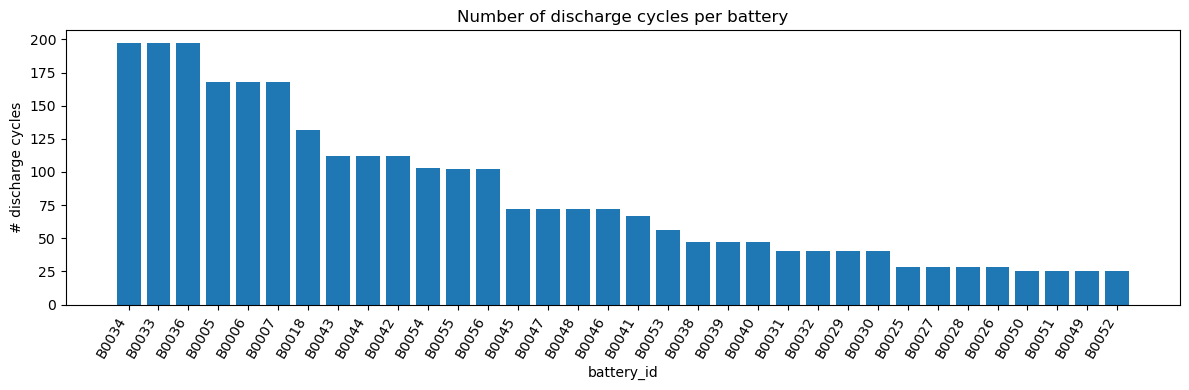

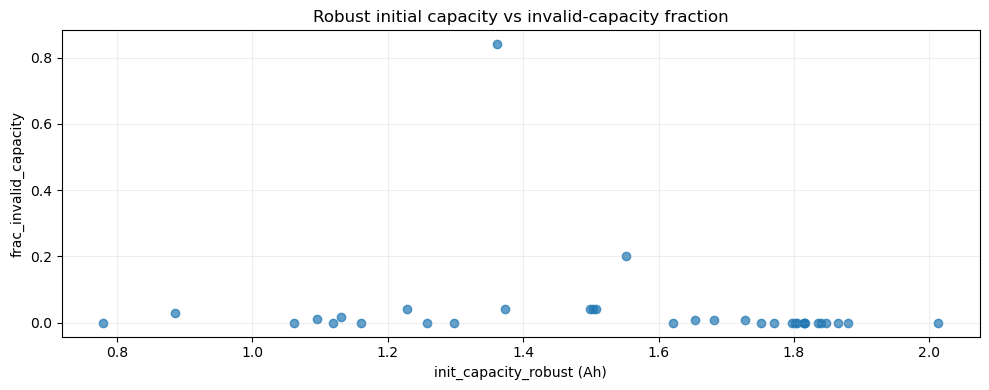

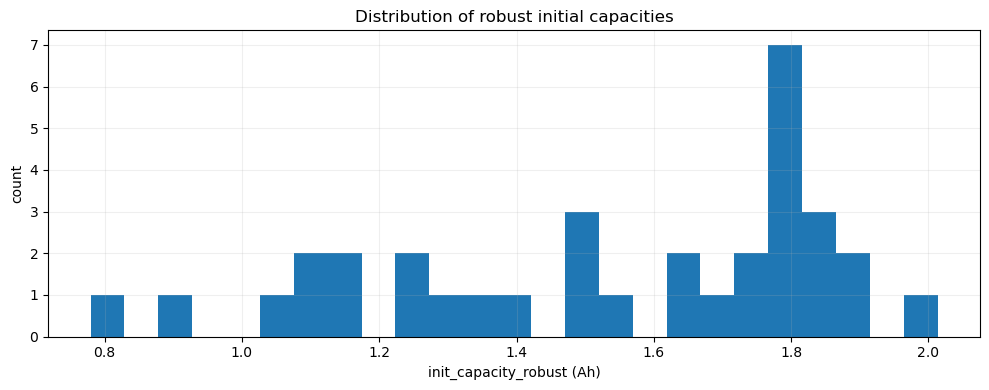

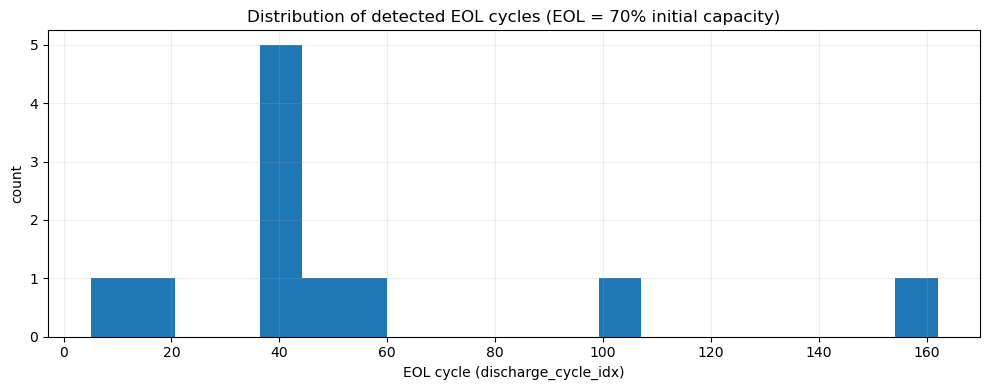

,battery_id,init_capacity_robust,n_valid_capacity,frac_invalid_capacity,temp_median_c,recommendation


In [61]:
# Extra EDA focused on battery quality and EOL coverage
plt.figure(figsize=(12, 4))
x = battery_quality.sort_values("n_discharge", ascending=False)
plt.bar(x["battery_id"].astype(str), x["n_discharge"].astype(int))
plt.title("Number of discharge cycles per battery")
plt.xlabel("battery_id")
plt.ylabel("# discharge cycles")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.scatter(battery_quality["init_capacity_robust"], battery_quality["frac_invalid_capacity"], alpha=0.7)
plt.title("Robust initial capacity vs invalid-capacity fraction")
plt.xlabel("init_capacity_robust (Ah)")
plt.ylabel("frac_invalid_capacity")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(battery_quality["init_capacity_robust"].dropna(), bins=25)
plt.title("Distribution of robust initial capacities")
plt.xlabel("init_capacity_robust (Ah)")
plt.ylabel("count")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(battery_quality.loc[battery_quality["has_eol"], "eol_cycle"].dropna(), bins=20)
plt.title("Distribution of detected EOL cycles (EOL = 70% initial capacity)")
plt.xlabel("EOL cycle (discharge_cycle_idx)")
plt.ylabel("count")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Quick look: batteries with very low initial capacity (often corrupted / different experiment regime)
display(battery_quality.loc[battery_quality["flag_very_low_init"], ["battery_id", "init_capacity_robust", "n_valid_capacity", "frac_invalid_capacity", "temp_median_c", "recommendation"]])

### How to “fix” batteries with intermittent bad capacity values
If a battery is tagged **FIXABLE**, the typical issue is a short segment of capacity values that are inconsistent with the local trend (spikes/drops).
A conservative, modeling-safe approach is:
1) **Avoid aggressive imputation**; instead mark those points as missing and exclude them from training.
2) If gap filling is required (e.g., for sequence models), only interpolate *short* missing runs and keep a mask feature indicating which points were filled.

Practical rules used above:
- **Zeros** were treated as invalid (`Capacity == 0 → NaN`).
- **Outliers** were detected via a rolling median + MAD-based threshold and counted (not automatically replaced).
- **Very-low initial capacity** (`< 0.5 Ah` robust init) is flagged as likely corrupted and recommended for exclusion.

Optionally, an additional cell can be added to create `capacity_clean_ah` per battery (outlier removal + limited interpolation) and then recompute SOH/EOL/RUL on that cleaned series.

In [62]:
report = {}
report["metadata_rows"] = int(len(meta))
report["metadata_unique_batteries"] = int(meta["battery_id"].nunique())
report["metadata_missing_files"] = int((~meta["file_exists"]).sum())
report["metadata_missing_start_ts"] = int(meta["start_ts"].isna().sum())
report["discharge_rows"] = int(len(dis))
report["discharge_missing_capacity"] = int(dis["Capacity"].isna().sum())
report["discharge_zero_capacity"] = int((dis["Capacity"] == 0).sum())
report["impedance_rows"] = int(len(imp))
report["impedance_missing_Re"] = int(imp["Re"].isna().sum())
report["impedance_missing_Rct"] = int(imp["Rct"].isna().sum())

quality_report = pd.Series(report).to_frame("value")
display(quality_report)

# Batteries with the lowest initial capacity (after cleaning)
init_caps = dis.groupby("battery_id")["capacity_init_ah"].first().sort_values()
display(init_caps.head(15).to_frame("init_capacity_ah"))

# Batteries with the highest fraction of invalid/zero capacities
invalid_frac = dis.groupby("battery_id")["capacity_ah"].apply(lambda s: s.isna().mean()).sort_values(ascending=False)
display((invalid_frac * 100).head(15).to_frame("%_invalid_capacity"))

print("\nNote: The screening table in section 6.1 provides a consolidated recommendation per battery.")

,value
metadata_rows,7565
metadata_unique_batteries,34
metadata_missing_files,0
metadata_missing_start_ts,0
discharge_rows,2794
discharge_missing_capacity,25
discharge_zero_capacity,19
impedance_rows,1956
impedance_missing_Re,9
impedance_missing_Rct,9


,init_capacity_ah
battery_id,
B0041,0.055620
B0033,0.068426
B0039,0.119038
B0051,0.643474
B0040,0.673463
B0054,0.739935
B0034,0.745930
B0056,0.785278
B0055,0.799000


,%_invalid_capacity
battery_id,
B0052,84.000000
B0050,20.000000
B0048,4.166667
B0047,4.166667
B0046,4.166667
B0049,4.000000
B0051,4.000000
B0045,2.777778
B0053,1.785714



Note: The screening table in section 6.1 provides a consolidated recommendation per battery.
